In [ ]:
# Data Cleaning
# EDA


In [ ]:
import os
import zipfile
import pandas as pd
import re
import time
import pyarrow as pa


# Set the path to your root folder containing all the historical_data_XXXX folders
BASE_DIR = r'D:\AI'
OUTPUT_DIR = r'D:\AI'  # <-- CHANGE THIS to a drive with space!

orig_header_path = r'D:\AI\origination_data_file_header.txt'
perf_header_path = r'D:\AI\performance_data_file_header.txt'

# Ensure the output folder exists
os.makedirs(OUTPUT_DIR, exist_ok=True)


# Create dedicated folders for the two datasets
orig_output_dir = os.path.join(OUTPUT_DIR, 'master_orig_dataset')
perf_output_dir = os.path.join(OUTPUT_DIR, 'master_perf_dataset')
os.makedirs(orig_output_dir, exist_ok=True)
os.makedirs(perf_output_dir, exist_ok=True)

# --- 2. LOAD HEADERS ---
print("Loading headers...")
orig_columns = pd.read_csv(orig_header_path, sep="|", header=0, nrows=1).columns.tolist()
perf_columns = pd.read_csv(perf_header_path, sep="|", header=0, nrows=1).columns.tolist()

print("Starting processing. This will compress the data significantly.\n")
start_time = time.time()
files_processed = 0


# --- 3. PROCESS AND SAVE AS PARTITIONED PARQUET ---
for root, dirs, files in os.walk(BASE_DIR):
    for file in files:
        if file.endswith('.zip'):
            zip_path = os.path.join(root, file)
            print(f"Processing: {file}")
            
            with zipfile.ZipFile(zip_path, 'r') as z:
                orig_files = [f for f in z.namelist() if os.path.basename(f).startswith('orig_') and f.endswith('.txt')]
                perf_files = [f for f in z.namelist() if os.path.basename(f).startswith('perf_') and f.endswith('.txt')]
                
                # --- PROCESS ORIG ---
                if orig_files:
                    orig_file = orig_files[0]
                    quarter_match = re.search(r'(\d{4}Q\d)', orig_file)
                    quarter = quarter_match.group(1) if quarter_match else 'Unknown'
                    
                    # FIX: Removed index_col=False to satisfy the pyarrow engine
                    df_quarter = pd.read_csv(z.open(orig_file), sep="|", header=None, engine='pyarrow')
                    df_quarter.columns = orig_columns
                    df_quarter['quarter'] = quarter
                    
                    # Save directly to compressed parquet
                    parquet_path = os.path.join(orig_output_dir, f'orig_{quarter}.parquet')
                    df_quarter.to_parquet(parquet_path, compression='zstd', index=False)
                        
                # --- PROCESS PERF ---
                if perf_files:
                    perf_file = perf_files[0]
                    quarter_match = re.search(r'(\d{4}Q\d)', perf_file)
                    quarter = quarter_match.group(1) if quarter_match else 'Unknown'
                    
                    # FIX: Removed index_col=False to satisfy the pyarrow engine
                    df_quarter = pd.read_csv(z.open(perf_file), sep="|", header=None, engine='pyarrow')
                    df_quarter.columns = perf_columns
                    df_quarter['quarter'] = quarter
                    
                    parquet_path = os.path.join(perf_output_dir, f'perf_{quarter}.parquet')
                    df_quarter.to_parquet(parquet_path, compression='zstd', index=False)
            
            files_processed += 1

# --- 4. WRAP UP ---
end_time = time.time()
total_minutes = round((end_time - start_time) / 60, 2)

print(f"\n🎉 SUCCESS!")
print(f"Processed {files_processed} zip files in {total_minutes} minutes.")
print(f"Orig data saved to: {orig_output_dir}")
print(f"Perf data saved to: {perf_output_dir}")


In [ ]:
# Creating fordward looking sample

import duckdb
import time
import os


# --- PATHS ---
ORIG_PARQUET_PATH = r'D:\AI\master_orig_dataset\*.parquet'
PERF_PARQUET_PATH = r'D:\AI\master_perf_dataset\*.parquet'
SAMPLED_IDS_PATH = 'D:/AI/sampled_loan_ids_10pct.parquet'
OUTPUT_PATH = 'D:/AI/dtsa_sample_forward_looking.parquet'

os.makedirs(r'D:\AI', exist_ok=True)

# --- CONFIGURE DUCKDB ---
con = duckdb.connect()
con.execute("SET memory_limit='75GB';")
con.execute("SET threads=28;")

# ============================================================
# STEP 1: Extract sampled Loan IDs (if not already done)
# ============================================================
if not os.path.exists(SAMPLED_IDS_PATH):
    print("Step 1: Extracting 10% sampled Loan IDs...")
    step1_start = time.time()
    
    step1_query = f"""
        COPY (
            SELECT "LOAN IDENTIFIER"
            FROM read_parquet('{ORIG_PARQUET_PATH}', union_by_name=true)
            USING SAMPLE 10 PERCENT
        ) TO '{SAMPLED_IDS_PATH}' (FORMAT PARQUET, COMPRESSION ZSTD);
    """
    con.execute(step1_query)
    print(f"✅ Step 1 complete in {time.time() - step1_start:.2f} seconds.")
else:
    print(f"✅ Sampled IDs file already exists: {SAMPLED_IDS_PATH}")

# ============================================================
# STEP 2: Main processing with BOTH 12m and 18m horizons
# ============================================================
print("\nStep 2: Processing features and creating forward-looking targets...")
step2_start = time.time()

step2_query = f"""
    COPY (
        WITH sampled_ids AS (
            SELECT "LOAN IDENTIFIER"
            FROM read_parquet('{SAMPLED_IDS_PATH}')
        ),
        base_data AS (
            SELECT 
                p."LOAN IDENTIFIER", p."PERIOD", p."LOAN AGE",
                
                -- CONTINUOUS CLEANING
                CASE WHEN CAST(o."CLASSIC FICO" AS VARCHAR) IN ('9999') THEN NULL 
                     ELSE TRY_CAST(o."CLASSIC FICO" AS INTEGER) END AS CLASSIC_FICO,
                CASE WHEN CAST(o."ORIGINAL LOAN-TO-VALUE (LTV)" AS VARCHAR) IN ('999') THEN NULL 
                     ELSE TRY_CAST(o."ORIGINAL LOAN-TO-VALUE (LTV)" AS INTEGER) END AS ORIGINAL_LTV,
                CASE WHEN CAST(o."ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)" AS VARCHAR) IN ('999') THEN NULL 
                     ELSE TRY_CAST(o."ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)" AS INTEGER) END AS ORIGINAL_CLTV,
                CASE WHEN CAST(o."ORIGINAL DEBT-TO-INCOME (DTI) RATIO" AS VARCHAR) IN ('999') THEN NULL 
                     ELSE TRY_CAST(o."ORIGINAL DEBT-TO-INCOME (DTI) RATIO" AS INTEGER) END AS ORIGINAL_DTI,
                CASE WHEN CAST(p."ESTIMATED LOAN-TO-VALUE (ELTV)" AS VARCHAR) IN ('999') THEN NULL 
                     ELSE TRY_CAST(p."ESTIMATED LOAN-TO-VALUE (ELTV)" AS INTEGER) END AS ELTV,
                
                CASE 
                    WHEN TRY_CAST(p."CURRENT INTEREST RATE" AS DOUBLE) IS NOT NULL 
                     AND TRY_CAST(o."ORIGINAL INTEREST RATE" AS DOUBLE) IS NOT NULL 
                    THEN TRY_CAST(p."CURRENT INTEREST RATE" AS DOUBLE) - TRY_CAST(o."ORIGINAL INTEREST RATE" AS DOUBLE)
                    ELSE NULL 
                END AS PAYMENT_SHOCK,
                
                -- CATEGORICAL CLEANING
                CASE WHEN CAST(o."CHANNEL" AS VARCHAR) IN ('9') THEN 'Missing' ELSE CAST(o."CHANNEL" AS VARCHAR) END AS CHANNEL,
                CASE WHEN CAST(o."OCCUPANCY STATUS" AS VARCHAR) IN ('9') THEN 'Missing' ELSE CAST(o."OCCUPANCY STATUS" AS VARCHAR) END AS OCCUPANCY_STATUS,
                CASE WHEN CAST(o."LOAN PURPOSE" AS VARCHAR) IN ('9') THEN 'Missing' ELSE CAST(o."LOAN PURPOSE" AS VARCHAR) END AS LOAN_PURPOSE,
                CASE WHEN CAST(o."FIRST TIME HOMEBUYER INDICATOR" AS VARCHAR) IN ('9') THEN 'Missing' ELSE CAST(o."FIRST TIME HOMEBUYER INDICATOR" AS VARCHAR) END AS FIRST_TIME_HOMEBUYER,
                CASE WHEN CAST(o."NUMBER OF UNITS" AS VARCHAR) IN ('99') THEN 'Missing' ELSE CAST(o."NUMBER OF UNITS" AS VARCHAR) END AS NUMBER_OF_UNITS,
                CASE WHEN CAST(o."PROPERTY TYPE" AS VARCHAR) IN ('99') THEN 'Missing' ELSE CAST(o."PROPERTY TYPE" AS VARCHAR) END AS PROPERTY_TYPE,
                CASE WHEN p."BORROWER ASSISTANCE PLAN" IS NULL THEN 'No_Plan' ELSE CAST(p."BORROWER ASSISTANCE PLAN" AS VARCHAR) END AS BORROWER_ASSISTANCE_PLAN,
                
                o."AMORTIZATION TYPE", o."ORIGINAL LOAN TERM", o."ORIGINAL UPB",
                p."CURRENT ACTUAL UPB", p."CURRENT INTEREST RATE", p."MODIFICATION FLAG",
                p."CURRENT LOAN DELINQUENCY STATUS", p."ZERO BALANCE CODE",
                
                -- POINT-IN-TIME DEFAULT
                CASE 
                    WHEN p."CURRENT LOAN DELINQUENCY STATUS" IN ('RA') THEN 1
                    WHEN p."CURRENT LOAN DELINQUENCY STATUS" NOT IN ('XX', '00', '01', '02') 
                         AND p."CURRENT LOAN DELINQUENCY STATUS" ~ '^[0-9]+$' 
                         AND TRY_CAST(p."CURRENT LOAN DELINQUENCY STATUS" AS INTEGER) >= 3 THEN 1
                    WHEN p."ZERO BALANCE CODE" IN ('03', '09') THEN 1
                    ELSE 0 
                END AS default_event

            FROM read_parquet('{PERF_PARQUET_PATH}', union_by_name=true) p
            INNER JOIN sampled_ids s ON p."LOAN IDENTIFIER" = s."LOAN IDENTIFIER"
            INNER JOIN read_parquet('{ORIG_PARQUET_PATH}', union_by_name=true) o ON p."LOAN IDENTIFIER" = o."LOAN IDENTIFIER"
        ),
        censored_data AS (
            SELECT *,
                LAG(CASE WHEN default_event = 1 OR "ZERO BALANCE CODE" IS NOT NULL THEN 1 ELSE 0 END) 
                OVER(PARTITION BY "LOAN IDENTIFIER" ORDER BY "PERIOD") as terminated_prev_month
            FROM base_data
        ),

        -- FORWARD-LOOKING WINDOWS
        forward_looking AS (
            SELECT 
                * EXCLUDE ("ZERO BALANCE CODE", "terminated_prev_month"),
                
                -- 12-MONTH HORIZON
                MAX(default_event) OVER (
                    PARTITION BY "LOAN IDENTIFIER" 
                    ORDER BY "PERIOD" 
                    ROWS BETWEEN 1 FOLLOWING AND 12 FOLLOWING
                ) AS default_in_next_12m,
                
                MAX(CASE WHEN "ZERO BALANCE CODE" IS NOT NULL THEN 1 ELSE 0 END) OVER (
                    PARTITION BY "LOAN IDENTIFIER" 
                    ORDER BY "PERIOD" 
                    ROWS BETWEEN 1 FOLLOWING AND 12 FOLLOWING
                ) AS terminates_in_next_12m,
                
                COUNT(*) OVER (
                    PARTITION BY "LOAN IDENTIFIER" 
                    ORDER BY "PERIOD" 
                    ROWS BETWEEN 1 FOLLOWING AND 12 FOLLOWING
                ) AS future_months_12m,
                
                -- 18-MONTH HORIZON
                MAX(default_event) OVER (
                    PARTITION BY "LOAN IDENTIFIER" 
                    ORDER BY "PERIOD" 
                    ROWS BETWEEN 1 FOLLOWING AND 18 FOLLOWING
                ) AS default_in_next_18m,
                
                MAX(CASE WHEN "ZERO BALANCE CODE" IS NOT NULL THEN 1 ELSE 0 END) OVER (
                    PARTITION BY "LOAN IDENTIFIER" 
                    ORDER BY "PERIOD" 
                    ROWS BETWEEN 1 FOLLOWING AND 18 FOLLOWING
                ) AS terminates_in_next_18m,
                
                COUNT(*) OVER (
                    PARTITION BY "LOAN IDENTIFIER" 
                    ORDER BY "PERIOD" 
                    ROWS BETWEEN 1 FOLLOWING AND 18 FOLLOWING
                ) AS future_months_18m

            FROM censored_data
            WHERE COALESCE(terminated_prev_month, 0) = 0
        ),

        feature_engineered AS (
            SELECT 
                -- FIXED: Don't exclude columns that were already excluded in forward_looking
                * EXCLUDE ("default_in_next_12m", "terminates_in_next_12m", "future_months_12m",
                           "default_in_next_18m", "terminates_in_next_18m", "future_months_18m"),
                
                -- 12-MONTH TARGET
                CASE 
                    WHEN future_months_12m < 12 THEN NULL
                    WHEN terminates_in_next_12m = 1 AND COALESCE(default_in_next_12m, 0) = 0 THEN NULL
                    WHEN COALESCE(default_in_next_12m, 0) = 1 THEN 1
                    ELSE 0
                END AS default_12m,
                
                -- 18-MONTH TARGET
                CASE 
                    WHEN future_months_18m < 18 THEN NULL
                    WHEN terminates_in_next_18m = 1 AND COALESCE(default_in_next_18m, 0) = 0 THEN NULL
                    WHEN COALESCE(default_in_next_18m, 0) = 1 THEN 1
                    ELSE 0
                END AS default_18m,
                
                CASE 
                    WHEN CAST(SUBSTRING("LOAN IDENTIFIER", 2, 2) AS INTEGER) = 99 THEN 1999
                    ELSE 2000 + CAST(SUBSTRING("LOAN IDENTIFIER", 2, 2) AS INTEGER)
                END AS ORIG_YEAR,
        
                ("CURRENT ACTUAL UPB" / NULLIF("ORIGINAL UPB", 0)) * 100 AS PROXY_LTV,
        
                CASE 
                    WHEN (CASE 
                            WHEN CAST(SUBSTRING("LOAN IDENTIFIER", 2, 2) AS INTEGER) = 99 THEN 1999
                            ELSE 2000 + CAST(SUBSTRING("LOAN IDENTIFIER", 2, 2) AS INTEGER)
                        END) <= 2015 THEN 'train'
                    WHEN (CASE 
                            WHEN CAST(SUBSTRING("LOAN IDENTIFIER", 2, 2) AS INTEGER) = 99 THEN 1999
                            ELSE 2000 + CAST(SUBSTRING("LOAN IDENTIFIER", 2, 2) AS INTEGER)
                        END) BETWEEN 2016 AND 2018 THEN 'val'
                    ELSE 'test'
                END AS data_split
            FROM forward_looking
        ),
        
        -- Filter out rows where BOTH targets are NULL
        clean_data AS (
            SELECT * FROM feature_engineered 
            WHERE default_12m IS NOT NULL OR default_18m IS NOT NULL
        ),
        
        downsampled_data AS (
            SELECT * FROM clean_data WHERE data_split IN ('val', 'test')
            UNION ALL
            SELECT * FROM clean_data WHERE data_split = 'train' AND (default_12m = 1 OR default_18m = 1)
            UNION ALL
            SELECT * FROM clean_data 
            WHERE data_split = 'train' AND COALESCE(default_12m, 0) = 0 AND COALESCE(default_18m, 0) = 0 AND RANDOM() < 0.10
        )
        SELECT * FROM downsampled_data
    ) TO '{OUTPUT_PATH}' (FORMAT PARQUET, COMPRESSION ZSTD);
"""


con.execute(step2_query)
print(f"✅ Step 2 complete in {time.time() - step2_start:.2f} seconds.")

# ============================================================
# VERIFICATION
# ============================================================
print(f"\n🎉 Total pipeline time: {time.time() - step2_start:.2f} seconds.")

count_query = f"""
    SELECT 
        data_split,
        COUNT(*) as total_rows,
        SUM(CASE WHEN default_12m = 1 THEN 1 ELSE 0 END) as defaults_12m,
        SUM(CASE WHEN default_12m = 0 THEN 1 ELSE 0 END) as non_defaults_12m,
        SUM(CASE WHEN default_12m IS NULL THEN 1 ELSE 0 END) as censored_12m,
        SUM(CASE WHEN default_18m = 1 THEN 1 ELSE 0 END) as defaults_18m,
        SUM(CASE WHEN default_18m = 0 THEN 1 ELSE 0 END) as non_defaults_18m,
        SUM(CASE WHEN default_18m IS NULL THEN 1 ELSE 0 END) as censored_18m
    FROM read_parquet('{OUTPUT_PATH}') 
    GROUP BY data_split
    ORDER BY data_split
"""
print("\nDataset Summary:")
print(con.execute(count_query).df().to_string(index=False))

con.close()

✅ Sampled IDs file already exists: D:/AI/sampled_loan_ids_10pct.parquet

Step 2: Processing features and creating forward-looking targets...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Step 2 complete in 1705.72 seconds.

🎉 Total pipeline time: 1705.72 seconds.

Dataset Summary:
data_split  total_rows  defaults_12m  non_defaults_12m  censored_12m  defaults_18m  non_defaults_18m  censored_18m
      test    41548238      260805.0        41287433.0           0.0      280250.0        34553038.0     6714950.0
     train     3740535     1469484.0         2271051.0           0.0     1914363.0         1458704.0      367468.0
       val    19138933      249767.0        18889166.0           0.0      327360.0        16397705.0     2413868.0


In [ ]:
##### Count unique loan records
import duckdb

# The *.parquet wildcard tells DuckDB to read all files in that folder
query = """
    SELECT COUNT(DISTINCT "LOAN IDENTIFIER") as total_unique_loans
    FROM read_parquet('D:\AI\master_orig_dataset\*.parquet')
"""

# Execute the query and fetch the result as a tiny Pandas DataFrame
result = duckdb.query(query).df()
print(f"Total unique loans in origination data: {result['total_unique_loans'].iloc[0]:,}")

In [ ]:
# Kaplan-Meier Survival Curve
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# --- 1. SET YOUR PATHS ---
# Point these to the folders where you saved your Parquet files
ORIG_PARQUET_PATH = r'D:\AI\master_orig_dataset'
PERF_PARQUET_PATH = r'D:\AI\master_perf_dataset'

print("Querying data with DuckDB... (This may take 1-3 minutes)")

# --- 2. ROBUST DUCKDB QUERY ---
# Notice: We now SELECT "OCCUPANCY STATUS" instead of "AMORTIZATION TYPE"
query = f"""
    WITH loan_outcomes AS (
        SELECT 
            "LOAN IDENTIFIER",
            CAST(MAX("LOAN AGE") AS INTEGER) AS final_age,
            CAST(MAX(CASE 
                WHEN "CURRENT LOAN DELINQUENCY STATUS" >= '03' THEN 1 
                WHEN "ZERO BALANCE CODE" IN ('03', '09') THEN 1 
                ELSE 0 
            END) AS INTEGER) AS event
        FROM read_parquet('{PERF_PARQUET_PATH}')
        GROUP BY "LOAN IDENTIFIER"
    )
    SELECT 
        TRIM(o."OCCUPANCY STATUS") AS OCCUPANCY_STATUS,
        lo.final_age,
        lo.event
    FROM loan_outcomes lo
    JOIN read_parquet('{ORIG_PARQUET_PATH}') o 
      ON lo."LOAN IDENTIFIER" = o."LOAN IDENTIFIER"
    WHERE TRIM(o."OCCUPANCY STATUS") IN ('P', 'I')
"""

df = duckdb.query(query).df()

print(f"Successfully aggregated {len(df):,} loans into memory.")
print("\nUnique Occupancy Statuses found:")
print(df["OCCUPANCY_STATUS"].value_counts())

# --- 3. DATA CLEANING (Crucial for lifelines) ---
# Drop any rows where age or event is missing
df = df.dropna(subset=['final_age', 'event'])

# Force numeric types to guarantee lifelines accepts them
df['final_age'] = df['final_age'].astype(int)
df['event'] = df['event'].astype(int)

# --- 4. SURVIVAL ANALYSIS WITH LIFELINES ---
plt.figure(figsize=(10, 6))

# Filter data for each group (Using the correct column name from SQL)
df_primary = df[df["OCCUPANCY_STATUS"] == "P"]
df_investment = df[df["OCCUPANCY_STATUS"] == "I"]

print(f"\nPrimary Residence (P) loans: {len(df_primary):,} | Investment (I) loans: {len(df_investment):,}")

# Initialize Kaplan-Meier fitters
kmf_primary = KaplanMeierFitter()
kmf_investment = KaplanMeierFitter()

# Fit Primary (Should always exist)
kmf_primary.fit(df_primary["final_age"], event_observed=df_primary["event"], label="Primary Residence (P)")
ax = kmf_primary.plot(ci_show=True, color="blue")

# Fit Investment (Only if we actually have Investment loans)
if len(df_investment) > 0:
    kmf_investment.fit(df_investment["final_age"], event_observed=df_investment["event"], label="Investment Property (I)")
    kmf_investment.plot(ax=ax, ci_show=True, color="red")
    
    # Statistical Significance (Log-Rank Test)
    results = logrank_test(
        df_primary["final_age"], df_investment["final_age"], 
        event_observed_A=df_primary["event"], event_observed_B=df_investment["event"]
    )
    print("\n--- Log-Rank Test Results ---")
    print(f"Test Statistic: {results.test_statistic:.2f}")
    print(f"P-Value: {results.p_value:.2e}")
else:
    print("\n⚠️ WARNING: No Investment loans found in this dataset. Plotting Primary only.")

# Formatting the plot
plt.title("Kaplan-Meier Survival Curve: Time to Default (Primary vs. Investment)")
plt.xlabel("Loan Age (Months)")
plt.ylabel("Probability of Survival (No Default)")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
### New Upload

import duckdb
import time
import os

NEW_TEMP_DIR = r"D:\AI\Temp"
os.makedirs(NEW_TEMP_DIR, exist_ok=True)
os.environ['TEMP'] = NEW_TEMP_DIR
os.environ['TMP'] = NEW_TEMP_DIR
print(f"✅ Temp directory forced to: {NEW_TEMP_DIR}")
# --- PATHS ---
ORIG_PARQUET_PATH = r'D:\AI\master_orig_dataset\*.parquet'
PERF_PARQUET_PATH = r'D:\AI\master_perf_dataset\*.parquet'
SAMPLED_IDS_PATH = 'D:/AI/sampled_loan_ids_10pct.parquet'
OUTPUT_PATH = 'D:/AI/dtsa_sample_final.parquet'

os.makedirs(r'D:\AI', exist_ok=True)

# --- CONFIGURE DUCKDB ---
con = duckdb.connect()
con.execute("SET memory_limit='50GB';")
con.execute("SET threads=28;")  # Use all your cores!

# ============================================================
# STEP 1: Extract sampled Loan IDs (Fast - ~1-2 minutes)
# ============================================================
print("Step 1: Extracting 10% sampled Loan IDs...")
step1_start = time.time()
con.execute("PRAGMA progress_bar_time = true;")

step1_query = f"""
    COPY (
        SELECT "LOAN IDENTIFIER"
        FROM read_parquet('{ORIG_PARQUET_PATH}', union_by_name=true)
        USING SAMPLE 10 PERCENT
    ) TO '{SAMPLED_IDS_PATH}' (FORMAT PARQUET, COMPRESSION ZSTD);
"""
con.execute(step1_query)
print(f"✅ Step 1 complete in {time.time() - step1_start:.2f} seconds.")

# ============================================================
# STEP 2: Main processing using the pre-sampled IDs
# ============================================================
print("\nStep 2: Processing features, splitting, and downsampling...")
step2_start = time.time()

step2_query = f"""
    COPY (
        WITH sampled_ids AS (
            -- Load the tiny pre-sampled ID file (instant)
            SELECT "LOAN IDENTIFIER"
            FROM read_parquet('{SAMPLED_IDS_PATH}')
        ),
        base_data AS (
            SELECT 
                p."LOAN IDENTIFIER", p."PERIOD", p."LOAN AGE",
                
                -- CONTINUOUS CLEANING
                CASE WHEN CAST(o."CLASSIC FICO" AS VARCHAR) IN ('9999') THEN NULL 
                     ELSE TRY_CAST(o."CLASSIC FICO" AS INTEGER) END AS CLASSIC_FICO,
                CASE WHEN CAST(o."ORIGINAL LOAN-TO-VALUE (LTV)" AS VARCHAR) IN ('999') THEN NULL 
                     ELSE TRY_CAST(o."ORIGINAL LOAN-TO-VALUE (LTV)" AS INTEGER) END AS ORIGINAL_LTV,
                CASE WHEN CAST(o."ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)" AS VARCHAR) IN ('999') THEN NULL 
                     ELSE TRY_CAST(o."ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)" AS INTEGER) END AS ORIGINAL_CLTV,
                CASE WHEN CAST(o."ORIGINAL DEBT-TO-INCOME (DTI) RATIO" AS VARCHAR) IN ('999') THEN NULL 
                     ELSE TRY_CAST(o."ORIGINAL DEBT-TO-INCOME (DTI) RATIO" AS INTEGER) END AS ORIGINAL_DTI,
                CASE WHEN CAST(p."ESTIMATED LOAN-TO-VALUE (ELTV)" AS VARCHAR) IN ('999') THEN NULL 
                     ELSE TRY_CAST(p."ESTIMATED LOAN-TO-VALUE (ELTV)" AS INTEGER) END AS ELTV,
                
                -- PAYMENT SHOCK
                CASE 
                    WHEN TRY_CAST(p."CURRENT INTEREST RATE" AS DOUBLE) IS NOT NULL 
                     AND TRY_CAST(o."ORIGINAL INTEREST RATE" AS DOUBLE) IS NOT NULL 
                    THEN TRY_CAST(p."CURRENT INTEREST RATE" AS DOUBLE) - TRY_CAST(o."ORIGINAL INTEREST RATE" AS DOUBLE)
                    ELSE NULL 
                END AS PAYMENT_SHOCK,
                
                -- CATEGORICAL CLEANING
                CASE WHEN CAST(o."CHANNEL" AS VARCHAR) IN ('9') THEN 'Missing' ELSE CAST(o."CHANNEL" AS VARCHAR) END AS CHANNEL,
                CASE WHEN CAST(o."OCCUPANCY STATUS" AS VARCHAR) IN ('9') THEN 'Missing' ELSE CAST(o."OCCUPANCY STATUS" AS VARCHAR) END AS OCCUPANCY_STATUS,
                CASE WHEN CAST(o."LOAN PURPOSE" AS VARCHAR) IN ('9') THEN 'Missing' ELSE CAST(o."LOAN PURPOSE" AS VARCHAR) END AS LOAN_PURPOSE,
                CASE WHEN CAST(o."FIRST TIME HOMEBUYER INDICATOR" AS VARCHAR) IN ('9') THEN 'Missing' ELSE CAST(o."FIRST TIME HOMEBUYER INDICATOR" AS VARCHAR) END AS FIRST_TIME_HOMEBUYER,
                CASE WHEN CAST(o."NUMBER OF UNITS" AS VARCHAR) IN ('99') THEN 'Missing' ELSE CAST(o."NUMBER OF UNITS" AS VARCHAR) END AS NUMBER_OF_UNITS,
                CASE WHEN CAST(o."PROPERTY TYPE" AS VARCHAR) IN ('99') THEN 'Missing' ELSE CAST(o."PROPERTY TYPE" AS VARCHAR) END AS PROPERTY_TYPE,
                CASE WHEN p."BORROWER ASSISTANCE PLAN" IS NULL THEN 'No_Plan' ELSE CAST(p."BORROWER ASSISTANCE PLAN" AS VARCHAR) END AS BORROWER_ASSISTANCE_PLAN,
                
                -- OTHER
                o."AMORTIZATION TYPE", o."ORIGINAL LOAN TERM", o."ORIGINAL UPB",
                p."CURRENT ACTUAL UPB", p."CURRENT INTEREST RATE", p."MODIFICATION FLAG",
                p."CURRENT LOAN DELINQUENCY STATUS", p."ZERO BALANCE CODE",
                
                -- FIXED TARGET VARIABLE
                CASE 
                    WHEN p."CURRENT LOAN DELINQUENCY STATUS" IN ('RA') THEN 1
                    WHEN p."CURRENT LOAN DELINQUENCY STATUS" NOT IN ('XX', '00', '01', '02') 
                         AND p."CURRENT LOAN DELINQUENCY STATUS" ~ '^[0-9]+$' 
                         AND TRY_CAST(p."CURRENT LOAN DELINQUENCY STATUS" AS INTEGER) >= 3 THEN 1
                    WHEN p."ZERO BALANCE CODE" IN ('03', '09') THEN 1
                    ELSE 0 
                END AS default_event

            FROM read_parquet('{PERF_PARQUET_PATH}', union_by_name=true) p
            -- Join to tiny ID table FIRST (acts as a filter)
            INNER JOIN sampled_ids s ON p."LOAN IDENTIFIER" = s."LOAN IDENTIFIER"
            -- Then get origination features
            INNER JOIN read_parquet('{ORIG_PARQUET_PATH}', union_by_name=true) o ON p."LOAN IDENTIFIER" = o."LOAN IDENTIFIER"
        ),
        censored_data AS (
            SELECT *,
                LAG(CASE WHEN default_event = 1 OR "ZERO BALANCE CODE" IS NOT NULL THEN 1 ELSE 0 END) 
                OVER(PARTITION BY "LOAN IDENTIFIER" ORDER BY "PERIOD") as terminated_prev_month
            FROM base_data
        ),
        


        feature_engineered AS (
            SELECT 
                * EXCLUDE ("ZERO BALANCE CODE", "terminated_prev_month"),
                CASE 
                    WHEN CAST(SUBSTRING("LOAN IDENTIFIER", 2, 2) AS INTEGER) = 99 THEN 1999
                    ELSE 2000 + CAST(SUBSTRING("LOAN IDENTIFIER", 2, 2) AS INTEGER)
                END AS ORIG_YEAR,
        
                ("CURRENT ACTUAL UPB" / NULLIF("ORIGINAL UPB", 0)) * 100 AS PROXY_LTV,
        
                CASE 
                    WHEN (CASE 
                            WHEN CAST(SUBSTRING("LOAN IDENTIFIER", 2, 2) AS INTEGER) = 99 THEN 1999
                            ELSE 2000 + CAST(SUBSTRING("LOAN IDENTIFIER", 2, 2) AS INTEGER)
                        END) <= 2015 THEN 'train'
                    WHEN (CASE 
                            WHEN CAST(SUBSTRING("LOAN IDENTIFIER", 2, 2) AS INTEGER) = 99 THEN 1999
                            ELSE 2000 + CAST(SUBSTRING("LOAN IDENTIFIER", 2, 2) AS INTEGER)
                        END) BETWEEN 2016 AND 2018 THEN 'val'
                    ELSE 'test'
                END AS data_split
            FROM censored_data
            WHERE COALESCE(terminated_prev_month, 0) = 0
        ),
        downsampled_data AS (
            SELECT * FROM feature_engineered WHERE data_split IN ('val', 'test')
            UNION ALL
            SELECT * FROM feature_engineered WHERE data_split = 'train' AND default_event = 1
            UNION ALL
            SELECT * FROM feature_engineered 
            WHERE data_split = 'train' AND default_event = 0 AND RANDOM() < 0.10
        )
        SELECT * FROM downsampled_data
    ) TO '{OUTPUT_PATH}' (FORMAT PARQUET, COMPRESSION ZSTD);
"""

con.execute(step2_query)
print(f"✅ Step 2 complete in {time.time() - step2_start:.2f} seconds.")

# ============================================================
# VERIFICATION
# ============================================================
print(f"\n🎉 Total pipeline time: {time.time() - step1_start:.2f} seconds.")

count_query = f"""
    SELECT data_split, default_event, COUNT(*) as row_count 
    FROM read_parquet('{OUTPUT_PATH}') 
    GROUP BY data_split, default_event 
    ORDER BY data_split, default_event
"""
print("\nDataset Summary:")
print(con.execute(count_query).df().to_string(index=False))

con.close()

✅ Temp directory forced to: D:\AI\Temp
Step 1: Extracting 10% sampled Loan IDs...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Step 1 complete in 1.42 seconds.

Step 2: Processing features, splitting, and downsampling...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [14]:
# Monte Carlo Simulation Set Up
import duckdb
import time
import os

NEW_TEMP_DIR = r"D:\AI\Temp"
os.makedirs(NEW_TEMP_DIR, exist_ok=True)
os.environ['TEMP'] = NEW_TEMP_DIR
os.environ['TMP'] = NEW_TEMP_DIR
print(f"✅ Temp directory forced to: {NEW_TEMP_DIR}")
# --- PATHS ---
ORIG_PARQUET_PATH = r'D:\AI\master_orig_dataset\*.parquet'
PERF_PARQUET_PATH = r'D:\AI\master_perf_dataset\*.parquet'
SAMPLED_IDS_PATH = 'D:/AI/sampled_loan_ids_10pct.parquet'
OUTPUT_PATH = 'D:/AI/monthly_pd.parquet'

os.makedirs(r'D:\AI', exist_ok=True)

# --- CONFIGURE DUCKDB ---
con = duckdb.connect()
con.execute("SET memory_limit='50GB';")
con.execute("SET threads=28;")  # Use all your cores!

# ============================================================
# STEP 1: Extract sampled Loan IDs (Fast - ~1-2 minutes)
# ============================================================
step1_start = time.time()
con.execute("PRAGMA progress_bar_time = true;")

# ============================================================
# STEP 2: Main processing using the pre-sampled IDs
# ============================================================
print("\nStep 2: Processing features, splitting, and downsampling...")
step2_start = time.time()

step2_query = f"""
    COPY (
        WITH sampled_ids AS (
            -- Load the tiny pre-sampled ID file (instant)
            SELECT "LOAN IDENTIFIER"
            FROM read_parquet('{SAMPLED_IDS_PATH}')
        ),
        base_data AS (
            SELECT 
                p."LOAN IDENTIFIER", p."PERIOD", p."LOAN AGE",
                
                -- credit score bucketing
                CASE 
                    WHEN TRY_CAST(o."CLASSIC FICO" AS INTEGER) IS NULL THEN 'Missing'
                    WHEN TRY_CAST(o."CLASSIC FICO" AS INTEGER) < 620 THEN 'Sub_620'
                    WHEN TRY_CAST(o."CLASSIC FICO" AS INTEGER) >= 620 AND TRY_CAST(o."CLASSIC FICO" AS INTEGER) < 679 THEN '620_to_679'
                    WHEN TRY_CAST(o."CLASSIC FICO" AS INTEGER) >= 680 AND TRY_CAST(o."CLASSIC FICO" AS INTEGER) < 739 THEN '680_to_739'
                    ELSE '740_plus'
                END AS CREDIT_SCORE_BUCKET,

                p."ACTUAL LOSS",

                -- Calculate total exposure (sum of the original loan balances)
                sum(o."ORIGINAL UPB") OVER(PARTITION BY p."LOAN IDENTIFIER") AS TOTAL_EXPOSURE,


                -- OTHER
                o."AMORTIZATION TYPE", o."ORIGINAL LOAN TERM", o."ORIGINAL UPB",
                p."CURRENT ACTUAL UPB", p."CURRENT INTEREST RATE", p."MODIFICATION FLAG",
                p."CURRENT LOAN DELINQUENCY STATUS", p."ZERO BALANCE CODE",
                
                -- FIXED TARGET VARIABLE
                CASE 
                    WHEN p."CURRENT LOAN DELINQUENCY STATUS" IN ('RA') THEN 1
                    WHEN p."CURRENT LOAN DELINQUENCY STATUS" NOT IN ('XX', '00', '01', '02') 
                         AND p."CURRENT LOAN DELINQUENCY STATUS" ~ '^[0-9]+$' 
                         AND TRY_CAST(p."CURRENT LOAN DELINQUENCY STATUS" AS INTEGER) >= 3 THEN 1
                    WHEN p."ZERO BALANCE CODE" IN ('03', '09') THEN 1
                    ELSE 0 
                END AS default_event,
                


            FROM read_parquet('{PERF_PARQUET_PATH}', union_by_name=true) p
            -- Join to tiny ID table FIRST (acts as a filter)
            INNER JOIN sampled_ids s ON p."LOAN IDENTIFIER" = s."LOAN IDENTIFIER"
            -- Then get origination features
            INNER JOIN read_parquet('{ORIG_PARQUET_PATH}', union_by_name=true) o ON p."LOAN IDENTIFIER" = o."LOAN IDENTIFIER"
        ),
        censored_data AS (
            SELECT *,
                LAG(CASE WHEN default_event = 1 OR "ZERO BALANCE CODE" IS NOT NULL THEN 1 ELSE 0 END) 
                OVER(PARTITION BY "LOAN IDENTIFIER" ORDER BY "PERIOD") as terminated_prev_month
            FROM base_data
        ),

        -- Step 1 Collapse monthly rows into one row per loan

        loan_level_outcomes AS (
            SELECT
                "LOAN IDENTIFIER",
                "CREDIT_SCORE_BUCKET",
                MAX("TOTAL_EXPOSURE") AS ORIGINAL_UPB,
                MAX(default_event) as is_defaulted,
                SUM(CASE WHEN "ZERO BALANCE CODE" IN ('03', '09') THEN "ACTUAL LOSS" ELSE 0 END) AS ESTIMATED_LOSS_AMOUNT, 
            FROM censored_data p
            GROUP BY "LOAN IDENTIFIER", "CREDIT_SCORE_BUCKET"
            ),

        -- Step 2 Aggregate by bucket and find PD and LGD
        bucketed_outcomes AS (
            SELECT 
                "CREDIT_SCORE_BUCKET",
                -- Total Exposure 
                SUM(ORIGINAL_UPB) AS TOTAL_EXPOSURE,
                -- Probability of Default (PD)
                SUM(is_defaulted) * 1.0 / COUNT("LOAN IDENTIFIER") AS PD,
                -- Loss Given Default (LGD)
                CASE 
                    WHEN SUM(CASE WHEN is_defaulted = 1 THEN ORIGINAL_UPB ELSE 0 END) > 0 
                    THEN SUM(estimated_loss_amount) * 1.0 / SUM(CASE WHEN is_defaulted = 1 THEN ORIGINAL_UPB ELSE 0 END)
                    ELSE 0 
                END AS LGD
            FROM loan_level_outcomes
            GROUP BY "CREDIT_SCORE_BUCKET"
        )

        SELECT * FROM bucketed_outcomes
    ) TO '{OUTPUT_PATH}' (FORMAT PARQUET, COMPRESSION ZSTD);
"""

con.execute(step2_query)
print(f"✅ Step 2 complete in {time.time() - step2_start:.2f} seconds.")



✅ Temp directory forced to: D:\AI\Temp

Step 2: Processing features, splitting, and downsampling...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Step 2 complete in 272.42 seconds.


--- Expected Loss per Bucket ---
  CREDIT_SCORE_BUCKET  Expected_Loss
0          680_to_739   7.111447e+08
1          620_to_679   6.061878e+08
2             Sub_620   1.507516e+08
3            740_plus   5.104600e+08

--- Portfolio Risk Metrics ---
Total Expected Loss (Average): $1,979,456,964.87
95% VaR (1-year):              $2,418,911,818.45
99% VaR (1-year):              $2,615,751,756.25


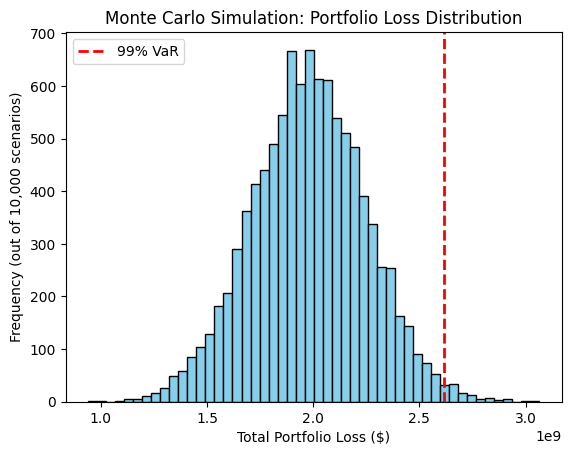

In [1]:
# Monte Carlo Simulation

import numpy as np
import pandas as pd


import time
import os

# --- PATHS ---
INPUT_PATH = r'D:\AI\monthly_pd.parquet'

df = pd.read_parquet(INPUT_PATH)

# Assuming your dataframe from DuckDB is loaded as 'df'
# df contains: CREDIT_SCORE_BUCKET, total_exposure, PD, LGD

# =========================================================================
# STEP 1: Calculate the "Anchor" (Expected Loss)
# =========================================================================
# Expected Loss (EL) is the mathematical average. 
# Formula: Exposure * Probability of Default * Loss Given Default
df['Expected_Loss'] = df['TOTAL_EXPOSURE'] * df['PD'] * df['LGD']

print("--- Expected Loss per Bucket ---")
print(df[['CREDIT_SCORE_BUCKET', 'Expected_Loss']])


# =========================================================================
# STEP 2: Set up the Simulation Parameters
# =========================================================================
num_simulations = 10000 # We will simulate 10,000 different "years"

# VOLATILITY: This is where we introduce uncertainty. 
# We are telling the model: "The actual loss in any given year might vary 
# by +/- 25% from our Expected Loss due to economic shocks."

volatility = 0.25 

# Create an empty list to hold the total portfolio loss for each scenario
portfolio_losses = []


# =========================================================================
# STEP 3: The Monte Carlo Set Up
# =========================================================================
# We loop 10,000 times. Each loop represents one possible future year.
for i in range(num_simulations):
    scenario_total_loss = 0
    
    # Inside the year, we look at each of our 4 risk buckets
    # (Note: We use .iterrows() here because our dataframe is only 4 rows. 
    # It is very easy to read and perfectly fine for small dataframes).
    for index, row in df.iterrows():
        
        expected = row['Expected_Loss']
        
        # THE DICE ROLL: 
        # np.random.normal generates a random number from a "Bell Curve" 
        # centered exactly on our Expected Loss.
        # 'loc' is the center (Expected Loss). 
        # 'scale' is how wide the bell curve is (our volatility).
        simulated_loss = np.random.normal(loc=expected, scale=expected * volatility)
        
        # Reality Check: A portfolio cannot have negative losses. 
        # If the random bell curve dips below zero, we cap it at $0.
        simulated_loss = max(0, simulated_loss)
        
        # Add this bucket's simulated loss to the total for the year
        scenario_total_loss += simulated_loss
        
    # Once all 4 buckets are calculated for this year, save the total
    portfolio_losses.append(scenario_total_loss)


# =========================================================================
# STEP 4: Calculate Value at Risk (VaR)
# =========================================================================
# Convert our list of 10,000 total losses into a numpy array for easy math
portfolio_losses = np.array(portfolio_losses)

# VaR is simply a percentile. 
# 99% VaR means: "Sort all 10,000 scenarios from lowest loss to highest loss. 
# The number at the 99th percentile is our VaR."
VaR_99 = np.percentile(portfolio_losses, 99)
VaR_95 = np.percentile(portfolio_losses, 95)

# Calculate the mathematical average (Expected Loss) of the whole portfolio
Total_Expected_Loss = np.mean(portfolio_losses)

print("\n--- Portfolio Risk Metrics ---")
print(f"Total Expected Loss (Average): ${Total_Expected_Loss:,.2f}")
print(f"95% VaR (1-year):              ${VaR_95:,.2f}")
print(f"99% VaR (1-year):              ${VaR_99:,.2f}")


import matplotlib.pyplot as plt

plt.hist(portfolio_losses, bins=50, color='skyblue', edgecolor='black')
plt.axvline(VaR_99, color='red', linestyle='dashed', linewidth=2, label='99% VaR')
plt.title("Monte Carlo Simulation: Portfolio Loss Distribution")
plt.xlabel("Total Portfolio Loss ($)")
plt.ylabel("Frequency (out of 10,000 scenarios)")
plt.legend()
plt.show()

In [3]:
#### Fred 
import pandas as pd
from fredapi import Fred
import numpy as np

# Initialize FRED with your API key
fred = Fred(api_key='badde7b0bf5a6441f7da522af157a338 ')


def get_vintage_data_clean(series_ids, fred_client):
    """
    Get vintage data and ensure proper data types
    """
    data_vintage = {}
    
    for name, series_id in series_ids.items():
        # Get vintage data
        raw_series = fred_client.get_series_first_release(series_id)
        
        # Convert to numeric, handling errors
        clean_series = pd.to_numeric(raw_series, errors='coerce')
        
        # Remove duplicates if any (keep last observation for each date)
        if clean_series.index.duplicated().any():
            clean_series = clean_series.groupby(clean_series.index).last()
        
        data_vintage[name] = clean_series
    
    # Combine into DataFrame
    df = pd.DataFrame(data_vintage)
    
    return df

# Usage
series_ids = {
    'GDP': 'GDP',
    'UNEMPLOYMENT_RATE': 'UNRATE',
    'HOME_PRICE_INDEX': 'CSUSHPISA',
}
data = get_vintage_data_clean(series_ids, fred)

# Combine into a DataFrame
df = pd.DataFrame(data)

# Resample to month-end
df = df.resample('ME').last()




df['GDP'] = df['GDP'].shift(2, axis=0, fill_value=pd.NA)

df['GDP'] = df['GDP'].interpolate(method='linear')
df['UNEMPLOYMENT_RATE'] = df['UNEMPLOYMENT_RATE'].interpolate(method='linear')

# Cut off at last full month, dynamically based on current date
#today = datetime.today()  # Gets current date and time
#last_week = today - timedelta(days=7)  # One week back
#last_full_month = last_week.replace(day=1) - timedelta(days=1)  # End of previous month
#df_full = df.loc[:last_full_month.strftime('%Y-%m-%d')].copy()

df['Date'] = pd.to_datetime(df.index, format='%Y%m')
df['Date'] = df['Date'].dt.strftime('%Y%m').astype(int)
df_short = df.loc['1990-01-01':'2025-12-31']
# Convert row names (index) to a column called 'Date'
#df_short = df_short.reset_index()
#df_short = df_short.rename(columns={'index': 'Date'})  # If your index is unnamed

# Or if your index already has a name:
#df_full = df_full.reset_index()


# Ensure Date column is properly formatted as datetime
#df_full['Date'] = pd.to_datetime(df_full.index, format='%Y-%m-%d')
#df_short.set_index('Date', inplace=True)



c:\Users\josep\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
c:\Users\josep\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
c:\Users\josep\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in 

In [4]:
### Creating test,val,train datasets for modeling

import pandas as pd
import os
import time

INPUT_PATH = r'D:\AI\dtsa_sample_forward_looking.parquet'
OUTPUT_DIR = r'D:\AI\dtsa_ml_ready'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Loading pre-processed dataset...")
start_time = time.time()
df1 = pd.read_parquet(INPUT_PATH)
print(f"✅ Loaded {len(df):,} rows in {time.time() - start_time:.2f} seconds.")


df = pd.merge(
    df_short, 
    df1, 
    left_on='Date', 
    right_on='PERIOD', 
    how='left'
)


print("Splitting and saving final datasets...")
# Because DuckDB already downsampled and labeled the data, we just filter!
df_train = df[df['data_split'] == 'train'].drop(columns=['data_split', 'ORIG_YEAR'])
df_val = df[df['data_split'] == 'val'].drop(columns=['data_split', 'ORIG_YEAR'])
df_test = df[df['data_split'] == 'test'].drop(columns=['data_split', 'ORIG_YEAR'])

print(f"  - Train: {len(df_train):,} rows (Default Rate: {df_train['default_event'].mean():.2%})")
print(f"  - Val:   {len(df_val):,} rows (Default Rate: {df_val['default_event'].mean():.2%})")
print(f"  - Test:  {len(df_test):,} rows (Default Rate: {df_test['default_event'].mean():.2%})")

print("\nSaving to Parquet...")
df_train.to_parquet(os.path.join(OUTPUT_DIR, 'train_balanced.parquet'), compression='zstd', index=False)
df_val.to_parquet(os.path.join(OUTPUT_DIR, 'val.parquet'), compression='zstd', index=False)
df_test.to_parquet(os.path.join(OUTPUT_DIR, 'test.parquet'), compression='zstd', index=False)

print("🎉 Phase 1 Complete! Ready for LightGBM training.")

Loading pre-processed dataset...
✅ Loaded 968 rows in 15.23 seconds.
Splitting and saving final datasets...
  - Train: 3,740,535 rows (Default Rate: 1.40%)
  - Val:   19,138,933 rows (Default Rate: 0.10%)
  - Test:  41,548,238 rows (Default Rate: 0.05%)

Saving to Parquet...
🎉 Phase 1 Complete! Ready for LightGBM training.


In [3]:
# summary stats
import os
import time
import pandas as pd


# --- 1. SET PATHS ---
DATA_DIR = r'D:\AI\dtsa_ml_ready'
MODEL_SAVE_PATH = os.path.join(DATA_DIR, 'dtsa_hazard_model.txt')

print("Loading datasets into memory...")
start_time = time.time()

# Load data
df_train = pd.read_parquet(os.path.join(DATA_DIR, 'train_balanced.parquet'))

print(df_train.columns)

Loading datasets into memory...
Index(['LOAN IDENTIFIER', 'PERIOD', 'LOAN AGE', 'CLASSIC_FICO', 'ORIGINAL_LTV',
       'ORIGINAL_CLTV', 'ORIGINAL_DTI', 'ELTV', 'PAYMENT_SHOCK', 'CHANNEL',
       'OCCUPANCY_STATUS', 'LOAN_PURPOSE', 'FIRST_TIME_HOMEBUYER',
       'NUMBER_OF_UNITS', 'PROPERTY_TYPE', 'BORROWER_ASSISTANCE_PLAN',
       'AMORTIZATION TYPE', 'ORIGINAL LOAN TERM', 'ORIGINAL UPB',
       'CURRENT ACTUAL UPB', 'CURRENT INTEREST RATE', 'MODIFICATION FLAG',
       'CURRENT LOAN DELINQUENCY STATUS', 'default_event', 'PROXY_LTV'],
      dtype='object')


Loading datasets into memory...
✅ Loaded in 22.16 seconds.
Train: 2,194,692 | Val: 21,337,894 | Test: 59,393,052

Training LightGBM Discrete-Time Hazard Model...
Training until validation scores don't improve for 100 rounds
[100]	val's average_precision: 0.193944
Early stopping, best iteration is:
[28]	val's average_precision: 0.211185
✅ Training completed in 112.68 seconds.
Best iteration: 28
Model saved to: D:\AI\dtsa_ml_ready\dtsa_hazard_model.txt

Evaluating on Test Set...
🎯 Test PR-AUC (Average Precision): 0.1320
🎯 Test ROC-AUC: 0.8891
🎯 Test Confusion Matrix:
[[59349544        0]
 [   43508        0]]
(Note: PR-AUC is the most important metric here due to the ~0.13% real-world default rate)

Calculating SHAP values for interpretability...


c:\Users\josep\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


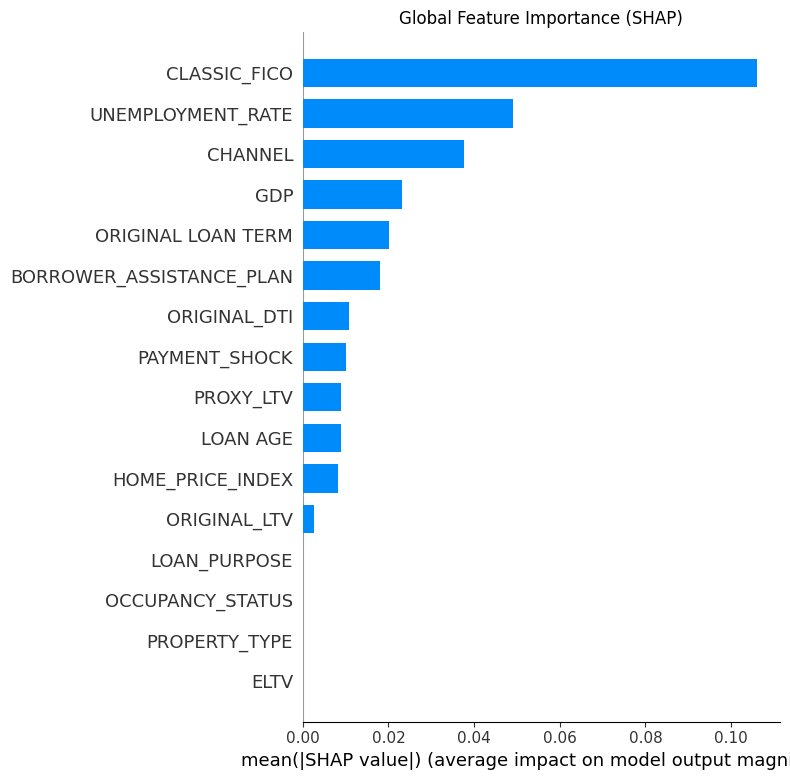

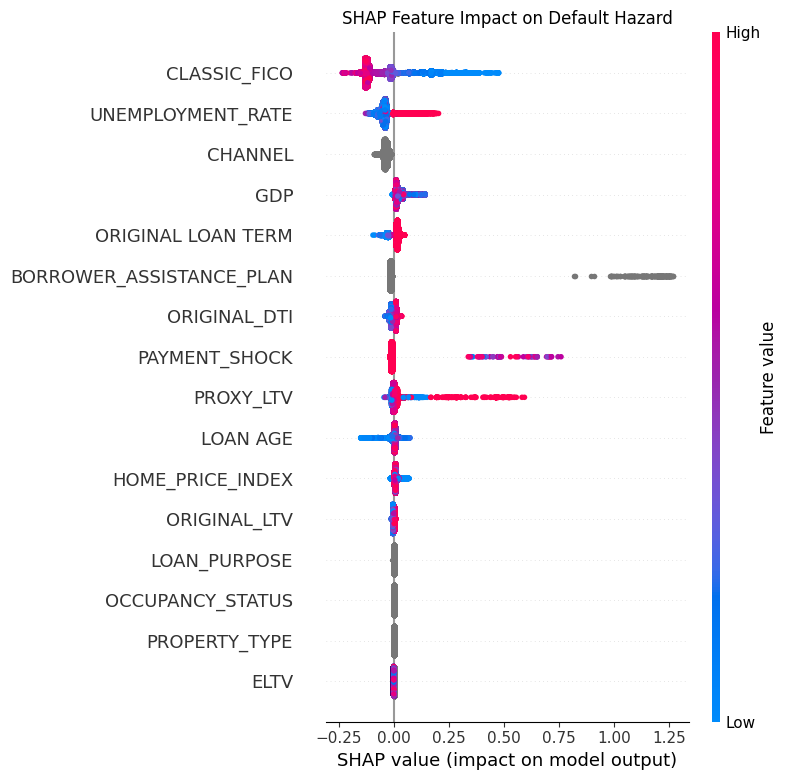


🎉 PHASE 3 COMPLETE!
You now have a trained, evaluated, and interpretable Discrete-Time Survival Model.


In [10]:
# GBM MODELING
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix
import time
import os

# --- 1. SET PATHS ---
DATA_DIR = r'D:\AI\dtsa_ml_ready'
MODEL_SAVE_PATH = os.path.join(DATA_DIR, 'dtsa_hazard_model.txt')

print("Loading datasets into memory...")
start_time = time.time()

# Load data
df_train = pd.read_parquet(os.path.join(DATA_DIR, 'train_balanced.parquet'))
df_val = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))
df_test = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))

print(f"✅ Loaded in {time.time() - start_time:.2f} seconds.")
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

# --- 2. FEATURE ENGINEERING & PREPROCESSING ---
# Drop identifier columns that shouldn't be used as predictive features
drop_cols = ['LOAN IDENTIFIER', 'PERIOD', 'CURRENT ACTUAL UPB', 'ORIGINAL UPB',
              'ESTIMATED LOAN-TO-VALUE (ELTV)', 'FIRST_TIME_HOMEBUYER',
              'CURRENT LOAN DELINQUENCY STATUS', 'NUMBER_OF_UNITS' , 'Date']
for df in [df_train, df_val, df_test]:
    df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Define target and features
target = 'default_event'
features = ['CLASSIC_FICO', 'PROXY_LTV', 'ORIGINAL LOAN TERM', 'LOAN AGE', 'GDP', 'UNEMPLOYMENT_RATE', 'HOME_PRICE_INDEX',
             'ORIGINAL_DTI', 'ORIGINAL_LTV', 'CHANNEL', 'ELTV', 'OCCUPANCY_STATUS', 'PAYMENT_SHOCK', 'BORROWER_ASSISTANCE_PLAN', 'PROPERTY_TYPE', 'LOAN_PURPOSE']

# Define categorical features (LightGBM handles these natively and powerfully)
categorical_features = [ 
    'CHANNEL',
    'OCCUPANCY_STATUS',
    'BORROWER_ASSISTANCE_PLAN',
    'PROPERTY_TYPE',
    'LOAN_PURPOSE'
]

# Convert categorical columns to 'category' dtype for LightGBM
for df in [df_train, df_val, df_test]:
    for col in categorical_features:
        if col in df.columns:
            df[col] = df[col].astype('category')

X_train, y_train = df_train[features], df_train[target]
X_val, y_val = df_val[features], df_val[target]
X_test, y_test = df_test[features], df_test[target]

# --- 3. MODEL CONFIGURATION ---
# We use Average Precision (PR-AUC) as the metric because defaults are rare
params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'learning_rate': 0.01,
    'num_leaves': 31,
    'max_depth': 10,          # Deeper trees capture interactions (e.g., Low FICO + High LTV)
    'min_child_samples': 100,# Prevents overfitting to tiny subgroups
    'feature_fraction': 0.8, # Randomly select 80% of features per tree (reduces overfitting)
    'bagging_fraction': 0.8, # Randomly select 80% of rows per tree
    'bagging_freq': 1,
    'verbose': -1,
    'n_jobs': -1             # Use all CPU cores
}

print("\nTraining LightGBM Discrete-Time Hazard Model...")
train_start = time.time()

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
lgb_val = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_features, reference=lgb_train)

# Train with early stopping
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1500,
    valid_sets=[lgb_val],
    valid_names=['val'],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)]
)

print(f"✅ Training completed in {time.time() - train_start:.2f} seconds.")
print(f"Best iteration: {model.best_iteration}")

# Save the model for future use
model.save_model(MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

# --- 4. EVALUATION ON HELD-OUT TEST SET ---
print("\nEvaluating on Test Set...")
y_pred_prob = model.predict(X_test, num_iteration=model.best_iteration)

pr_auc = average_precision_score(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)
confusion = confusion_matrix(y_test, (y_pred_prob >= 0.5).astype(int))

print(f"🎯 Test PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"🎯 Test ROC-AUC: {roc_auc:.4f}")
print(f"🎯 Test Confusion Matrix:\n{confusion}")
print("(Note: PR-AUC is the most important metric here due to the ~0.13% real-world default rate)")

# --- 5. SHAP INTERPRETABILITY (Answering your research questions) ---
print("\nCalculating SHAP values for interpretability...")
# Use a sample of the test set for SHAP to keep computation fast (e.g., 100,000 rows)
shap_sample = X_test.sample(n=100000, random_state=42)
shap_pred = model.predict(shap_sample, num_iteration=model.best_iteration)

# Initialize TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(shap_sample)

# Plot Global Feature Importance
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

# Plot SHAP Beeswarm (shows directionality: e.g., does High ELTV increase or decrease risk?)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title("SHAP Feature Impact on Default Hazard")
plt.tight_layout()
plt.show()

print("\n🎉 PHASE 3 COMPLETE!")
print("You now have a trained, evaluated, and interpretable Discrete-Time Survival Model.")




In [ ]:
# 1. Get the predicted probabilities for the test set
y_pred_prob = model.predict(X_test, num_iteration=model.best_iteration)

# 2. Choose a realistic business threshold (e.g., 0.05 or 0.10)
threshold = 0.2
y_pred_labels = (y_pred_prob >= threshold).astype(int)

# 3. Generate a labeled confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

print(f"\n--- Confusion Matrix at {threshold*100:.0f}% Threshold ---")
print(f"True Negatives (Correctly Safe):      {tn:,}")
print(f"False Positives (False Alarms):       {fp:,}")
print(f"False Negatives (Missed Defaults):    {fn:,}")
print(f"True Positives (Caught Defaults):     {tp:,}")

# 4. Calculate realistic business metrics
recall = tp / (tp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f"\nRecall (Capture Rate):    {recall:.2%}  <- Of all actual defaults, we caught this many.")
print(f"Precision (Accuracy):     {precision:.2%}  <- When we flag a default, we are right this often.")
print(f"Baseline Default Rate:    {(tp + fn) / len(y_test):.2%}")


Loading datasets into memory...
✅ Loaded in 17.71 seconds.
Train: 3,740,535 | Val: 19,138,933 | Test: 41,548,238

TRAINING MODEL 1: 12-MONTH DEFAULT PREDICTION

12m Dataset sizes (after removing censored rows):
  Train: 3,740,535 | Val: 19,138,933 | Test: 41,548,238
  Train default rate: 0.3929
  Val default rate: 0.0131
  Test default rate: 0.0063

Training 12-month model...
Training until validation scores don't improve for 100 rounds
[100]	val's average_precision: 0.161997
[200]	val's average_precision: 0.170766
[300]	val's average_precision: 0.172269
[400]	val's average_precision: 0.173156
[500]	val's average_precision: 0.173333
Early stopping, best iteration is:
[420]	val's average_precision: 0.173375
✅ 12m training completed in 589.10 seconds.
Best iteration: 420
Model saved to: D:\AI\dtsa_ml_ready\dtsa_default_12m_model.txt

Evaluating 12-month model on Test Set...
🎯 Test PR-AUC: 0.1158
🎯 Test ROC-AUC: 0.7997
🎯 Confusion Matrix:
[[14620814 26666619]
 [   15299   245506]]

Calcul

c:\Users\josep\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


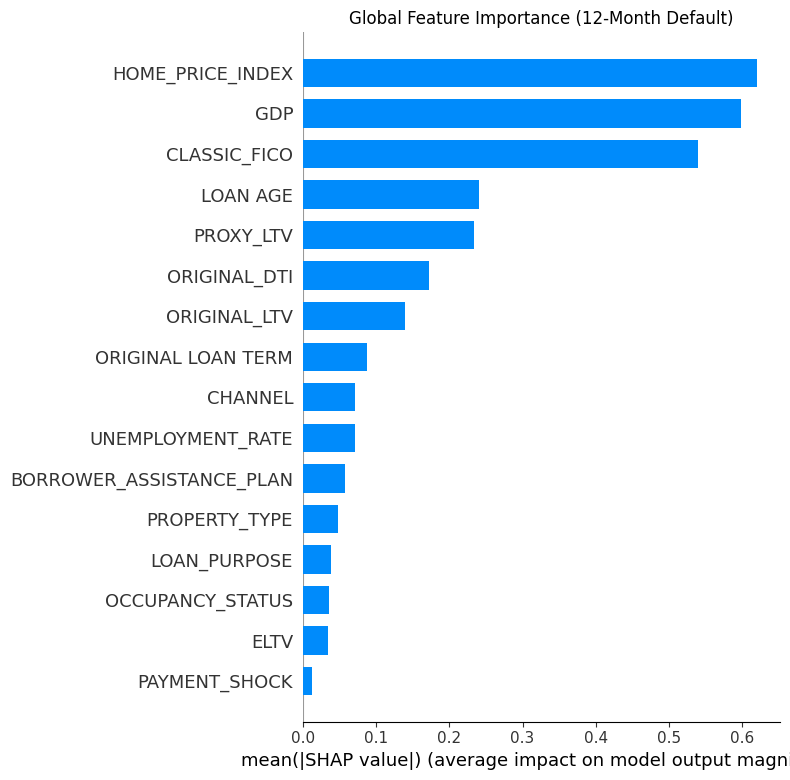

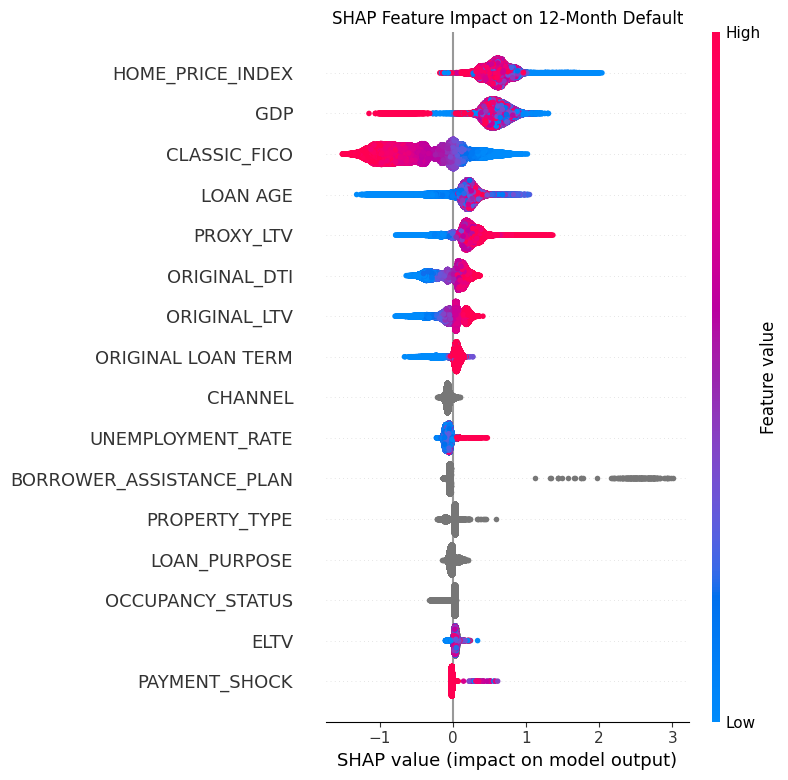


TRAINING MODEL 2: 18-MONTH DEFAULT PREDICTION

18m Dataset sizes (after removing censored rows):
  Train: 3,373,067 | Val: 16,725,065 | Test: 34,833,288
  Train default rate: 0.5675
  Val default rate: 0.0196
  Test default rate: 0.0080

Training 18-month model...
Training until validation scores don't improve for 100 rounds
[100]	val's average_precision: 0.155464
[200]	val's average_precision: 0.153216
Early stopping, best iteration is:
[117]	val's average_precision: 0.155829
✅ 18m training completed in 197.51 seconds.
Best iteration: 117
Model saved to: D:\AI\dtsa_ml_ready\dtsa_default_18m_model.txt

Evaluating 18-month model on Test Set...
🎯 Test PR-AUC: 0.1051
🎯 Test ROC-AUC: 0.8114
🎯 Confusion Matrix:
[[ 8140194 26412844]
 [    6911   273339]]

Calculating SHAP values for 18-month model...


c:\Users\josep\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


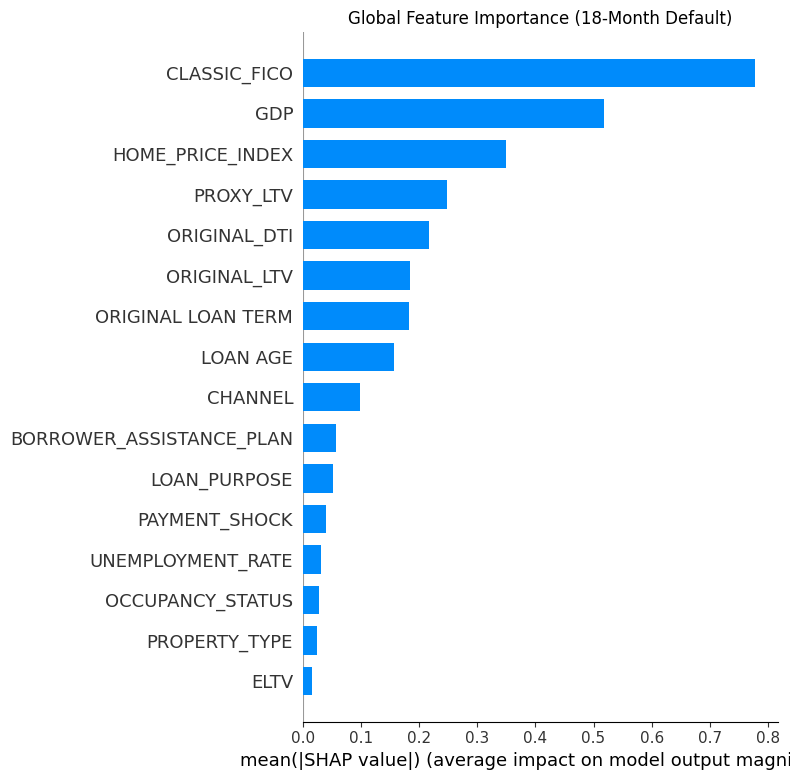

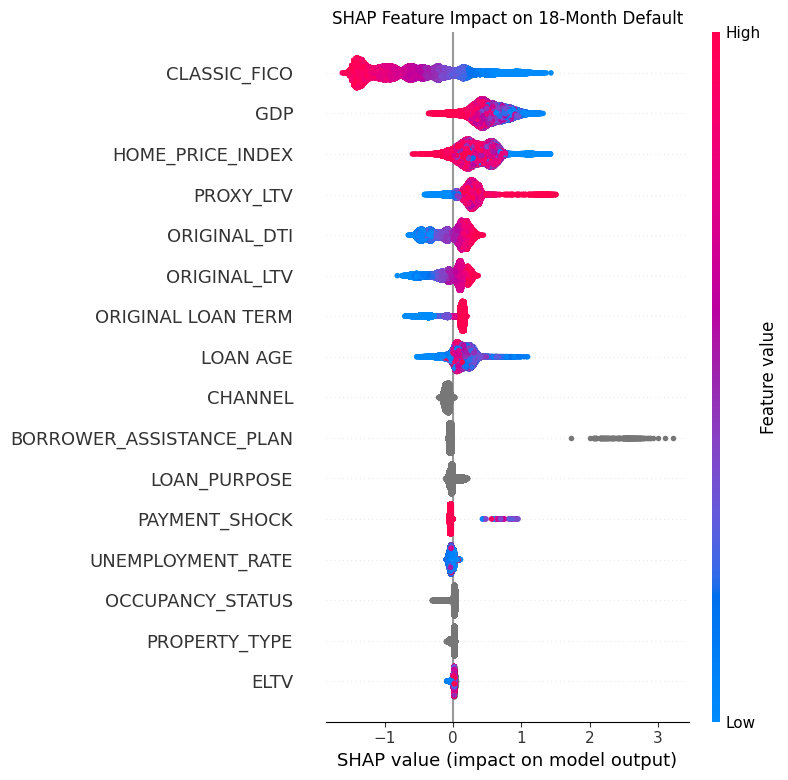


MODEL COMPARISON SUMMARY

12-Month Model:
  PR-AUC: 0.1158 | ROC-AUC: 0.7997
  Training samples: 3,740,535
  Test samples: 41,548,238

18-Month Model:
  PR-AUC: 0.1051 | ROC-AUC: 0.8114
  Training samples: 3,373,067
  Test samples: 34,833,288

🎉 BOTH MODELS COMPLETE!
12-month model saved to: D:\AI\dtsa_ml_ready\dtsa_default_12m_model.txt
18-month model saved to: D:\AI\dtsa_ml_ready\dtsa_default_18m_model.txt


In [1]:
# FORWARD-LOOKING DEFAULT PREDICTION MODELS (12m & 18m)
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix
import time
import os

# --- 1. SET PATHS ---
DATA_DIR = r'D:\AI\dtsa_ml_ready'
MODEL_12M_PATH = os.path.join(DATA_DIR, 'dtsa_default_12m_model.txt')
MODEL_18M_PATH = os.path.join(DATA_DIR, 'dtsa_default_18m_model.txt')

print("Loading datasets into memory...")
start_time = time.time()

# Load data
df_train = pd.read_parquet(os.path.join(DATA_DIR, 'train_balanced.parquet'))
df_val = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))
df_test = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))

print(f"✅ Loaded in {time.time() - start_time:.2f} seconds.")
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

# --- 2. FEATURE ENGINEERING & PREPROCESSING ---
drop_cols = ['LOAN IDENTIFIER', 'PERIOD', 'CURRENT ACTUAL UPB', 'ORIGINAL UPB',
             'ESTIMATED LOAN-TO-VALUE (ELTV)', 'FIRST_TIME_HOMEBUYER',
             'CURRENT LOAN DELINQUENCY STATUS', 'NUMBER_OF_UNITS', 'Date']  # Drop both targets initially

for df in [df_train, df_val, df_test]:
    df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Features (same as your current model)
features = ['CLASSIC_FICO', 'PROXY_LTV', 'ORIGINAL LOAN TERM', 'LOAN AGE', 'GDP', 'UNEMPLOYMENT_RATE', 'HOME_PRICE_INDEX',
            'ORIGINAL_DTI', 'ORIGINAL_LTV', 'CHANNEL', 'ELTV', 'OCCUPANCY_STATUS', 'PAYMENT_SHOCK', 
            'BORROWER_ASSISTANCE_PLAN', 'PROPERTY_TYPE', 'LOAN_PURPOSE']

categorical_features = [ 
    'CHANNEL',
    'OCCUPANCY_STATUS',
    'BORROWER_ASSISTANCE_PLAN',
    'PROPERTY_TYPE',
    'LOAN_PURPOSE'
]

# Convert categorical columns
for df in [df_train, df_val, df_test]:
    for col in categorical_features:
        if col in df.columns:
            df[col] = df[col].astype('category')

# Model parameters
params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 10,
    'min_child_samples': 100,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
    'n_jobs': -1
}

# ============================================================
# MODEL 1: 12-MONTH HORIZON
# ============================================================
print("\n" + "="*80)
print("TRAINING MODEL 1: 12-MONTH DEFAULT PREDICTION")
print("="*80)

# Prepare 12m data
df_train_12m = df_train[df_train['default_12m'].notna()].copy()
df_val_12m = df_val[df_val['default_12m'].notna()].copy()
df_test_12m = df_test[df_test['default_12m'].notna()].copy()

print(f"\n12m Dataset sizes (after removing censored rows):")
print(f"  Train: {len(df_train_12m):,} | Val: {len(df_val_12m):,} | Test: {len(df_test_12m):,}")
print(f"  Train default rate: {df_train_12m['default_12m'].mean():.4f}")
print(f"  Val default rate: {df_val_12m['default_12m'].mean():.4f}")
print(f"  Test default rate: {df_test_12m['default_12m'].mean():.4f}")

X_train_12m = df_train_12m[features]
y_train_12m = df_train_12m['default_12m'].astype(int)
X_val_12m = df_val_12m[features]
y_val_12m = df_val_12m['default_12m'].astype(int)
X_test_12m = df_test_12m[features]
y_test_12m = df_test_12m['default_12m'].astype(int)

print("\nTraining 12-month model...")
train_start = time.time()

lgb_train_12m = lgb.Dataset(X_train_12m, label=y_train_12m, categorical_feature=categorical_features)
lgb_val_12m = lgb.Dataset(X_val_12m, label=y_val_12m, categorical_feature=categorical_features, reference=lgb_train_12m)

model_12m = lgb.train(
    params,
    lgb_train_12m,
    num_boost_round=1500,
    valid_sets=[lgb_val_12m],
    valid_names=['val'],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)]
)

print(f"✅ 12m training completed in {time.time() - train_start:.2f} seconds.")
print(f"Best iteration: {model_12m.best_iteration}")
model_12m.save_model(MODEL_12M_PATH)
print(f"Model saved to: {MODEL_12M_PATH}")

# Evaluate 12m model
print("\nEvaluating 12-month model on Test Set...")
y_pred_prob_12m = model_12m.predict(X_test_12m, num_iteration=model_12m.best_iteration)

pr_auc_12m = average_precision_score(y_test_12m, y_pred_prob_12m)
roc_auc_12m = roc_auc_score(y_test_12m, y_pred_prob_12m)
confusion_12m = confusion_matrix(y_test_12m, (y_pred_prob_12m >= 0.5).astype(int))

print(f"🎯 Test PR-AUC: {pr_auc_12m:.4f}")
print(f"🎯 Test ROC-AUC: {roc_auc_12m:.4f}")
print(f"🎯 Confusion Matrix:\n{confusion_12m}")

# SHAP for 12m
print("\nCalculating SHAP values for 12-month model...")
shap_sample_12m = X_test_12m.sample(n=min(100000, len(X_test_12m)), random_state=42)
explainer_12m = shap.TreeExplainer(model_12m)
shap_values_12m = explainer_12m.shap_values(shap_sample_12m)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_12m, shap_sample_12m, plot_type="bar", show=False)
plt.title("Global Feature Importance (12-Month Default)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_12m, shap_sample_12m, show=False)
plt.title("SHAP Feature Impact on 12-Month Default")
plt.tight_layout()
plt.show()

# ============================================================
# MODEL 2: 18-MONTH HORIZON
# ============================================================
print("\n" + "="*80)
print("TRAINING MODEL 2: 18-MONTH DEFAULT PREDICTION")
print("="*80)

# Prepare 18m data
df_train_18m = df_train[df_train['default_18m'].notna()].copy()
df_val_18m = df_val[df_val['default_18m'].notna()].copy()
df_test_18m = df_test[df_test['default_18m'].notna()].copy()

print(f"\n18m Dataset sizes (after removing censored rows):")
print(f"  Train: {len(df_train_18m):,} | Val: {len(df_val_18m):,} | Test: {len(df_test_18m):,}")
print(f"  Train default rate: {df_train_18m['default_18m'].mean():.4f}")
print(f"  Val default rate: {df_val_18m['default_18m'].mean():.4f}")
print(f"  Test default rate: {df_test_18m['default_18m'].mean():.4f}")

X_train_18m = df_train_18m[features]
y_train_18m = df_train_18m['default_18m'].astype(int)
X_val_18m = df_val_18m[features]
y_val_18m = df_val_18m['default_18m'].astype(int)
X_test_18m = df_test_18m[features]
y_test_18m = df_test_18m['default_18m'].astype(int)

print("\nTraining 18-month model...")
train_start = time.time()

lgb_train_18m = lgb.Dataset(X_train_18m, label=y_train_18m, categorical_feature=categorical_features)
lgb_val_18m = lgb.Dataset(X_val_18m, label=y_val_18m, categorical_feature=categorical_features, reference=lgb_train_18m)

model_18m = lgb.train(
    params,
    lgb_train_18m,
    num_boost_round=1500,
    valid_sets=[lgb_val_18m],
    valid_names=['val'],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)]
)

print(f"✅ 18m training completed in {time.time() - train_start:.2f} seconds.")
print(f"Best iteration: {model_18m.best_iteration}")
model_18m.save_model(MODEL_18M_PATH)
print(f"Model saved to: {MODEL_18M_PATH}")

# Evaluate 18m model
print("\nEvaluating 18-month model on Test Set...")
y_pred_prob_18m = model_18m.predict(X_test_18m, num_iteration=model_18m.best_iteration)

pr_auc_18m = average_precision_score(y_test_18m, y_pred_prob_18m)
roc_auc_18m = roc_auc_score(y_test_18m, y_pred_prob_18m)
confusion_18m = confusion_matrix(y_test_18m, (y_pred_prob_18m >= 0.5).astype(int))

print(f"🎯 Test PR-AUC: {pr_auc_18m:.4f}")
print(f"🎯 Test ROC-AUC: {roc_auc_18m:.4f}")
print(f"🎯 Confusion Matrix:\n{confusion_18m}")

# SHAP for 18m
print("\nCalculating SHAP values for 18-month model...")
shap_sample_18m = X_test_18m.sample(n=min(100000, len(X_test_18m)), random_state=42)
explainer_18m = shap.TreeExplainer(model_18m)
shap_values_18m = explainer_18m.shap_values(shap_sample_18m)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_18m, shap_sample_18m, plot_type="bar", show=False)
plt.title("Global Feature Importance (18-Month Default)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_18m, shap_sample_18m, show=False)
plt.title("SHAP Feature Impact on 18-Month Default")
plt.tight_layout()
plt.show()

# ============================================================
# COMPARISON SUMMARY
# ============================================================
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
print(f"\n12-Month Model:")
print(f"  PR-AUC: {pr_auc_12m:.4f} | ROC-AUC: {roc_auc_12m:.4f}")
print(f"  Training samples: {len(df_train_12m):,}")
print(f"  Test samples: {len(df_test_12m):,}")

print(f"\n18-Month Model:")
print(f"  PR-AUC: {pr_auc_18m:.4f} | ROC-AUC: {roc_auc_18m:.4f}")
print(f"  Training samples: {len(df_train_18m):,}")
print(f"  Test samples: {len(df_test_18m):,}")

print("\n🎉 BOTH MODELS COMPLETE!")
print(f"12-month model saved to: {MODEL_12M_PATH}")
print(f"18-month model saved to: {MODEL_18M_PATH}")

Loading test data...
Evaluating on 34,833,288 loans (valid for both 12m and 18m horizons).
Actual 18m default rate in this set: 0.0080

Loading models and generating predictions...
Calculating Precision and Recall across thresholds...


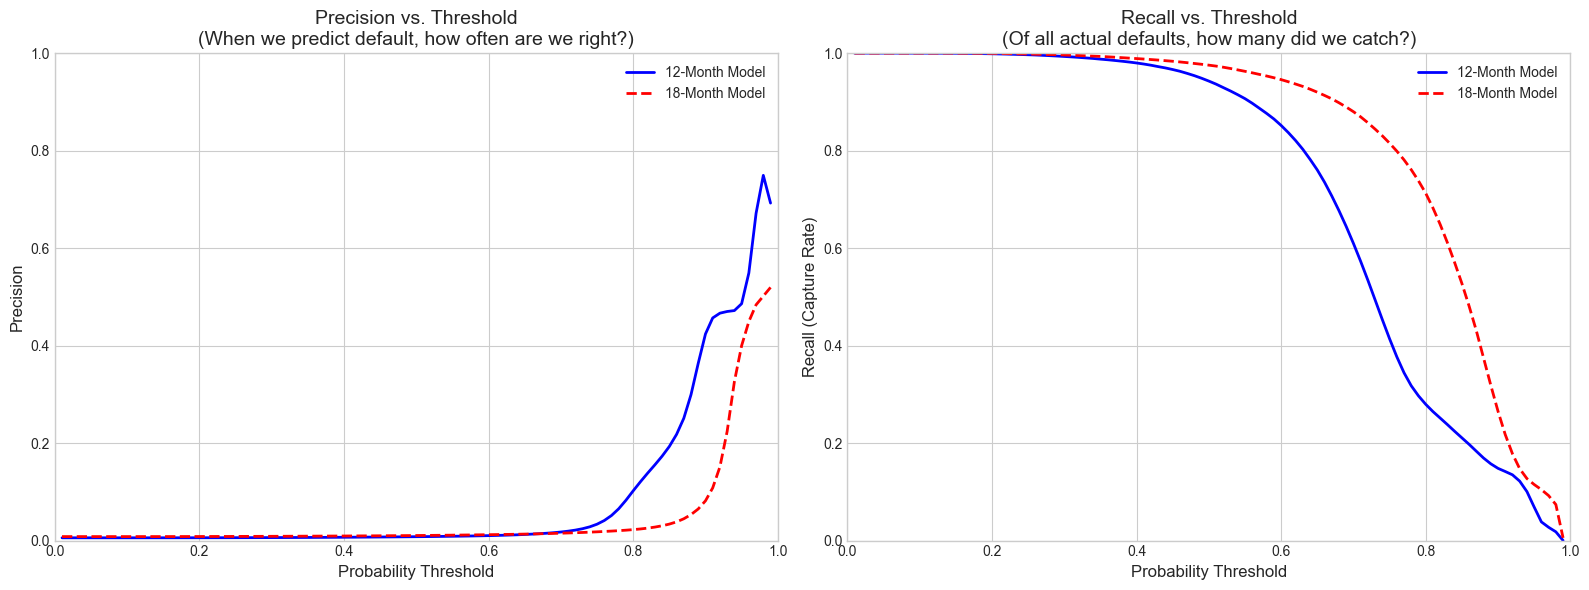

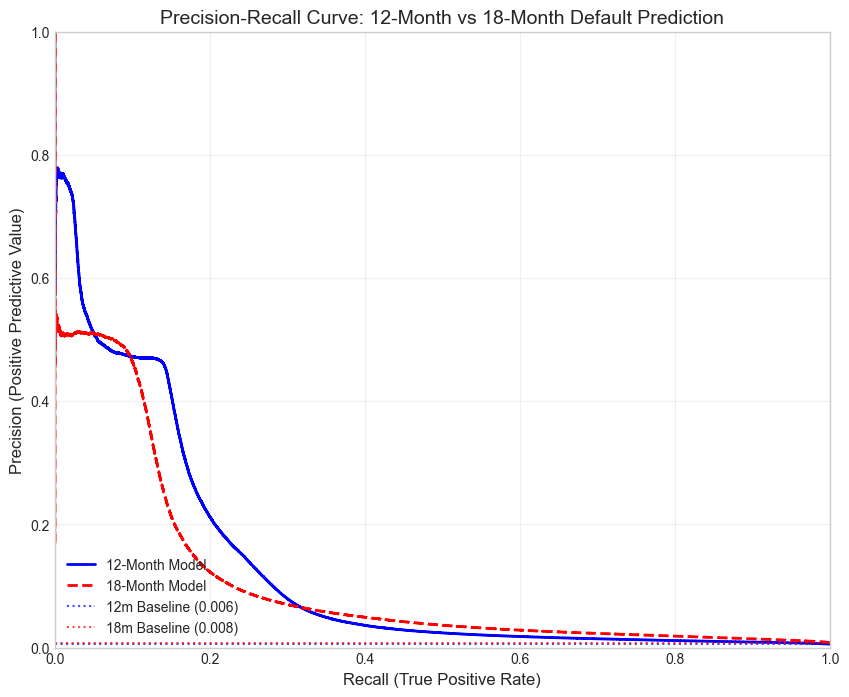


✅ Comparison plots generated successfully!


In [ ]:
# Default Prop model
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, precision_recall_curve
import os

# --- 1. SET PATHS & LOAD DATA ---
DATA_DIR = r'D:\AI\dtsa_ml_ready'
MODEL_12M_PATH = os.path.join(DATA_DIR, 'dtsa_default_12m_model.txt')
MODEL_18M_PATH = os.path.join(DATA_DIR, 'dtsa_default_18m_model.txt')

print("Loading test data...")
df_test = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))

# FILTER FOR FAIR COMPARISON: Only keep rows valid for the 18-month horizon
df_test_fair = df_test[df_test['default_18m'].notna()].copy()
print(f"Evaluating on {len(df_test_fair):,} loans (valid for both 12m and 18m horizons).")
print(f"Actual 18m default rate in this set: {df_test_fair['default_18m'].mean():.4f}")

# Define features and categoricals (must match training)
features = ['CLASSIC_FICO', 'PROXY_LTV', 'ORIGINAL LOAN TERM', 'LOAN AGE', 'GDP', 'UNEMPLOYMENT_RATE', 'HOME_PRICE_INDEX',
            'ORIGINAL_DTI', 'ORIGINAL_LTV', 'CHANNEL', 'ELTV', 'OCCUPANCY_STATUS', 'PAYMENT_SHOCK', 
            'BORROWER_ASSISTANCE_PLAN', 'PROPERTY_TYPE', 'LOAN_PURPOSE']

categorical_features = ['CHANNEL', 'OCCUPANCY_STATUS', 'BORROWER_ASSISTANCE_PLAN', 'PROPERTY_TYPE', 'LOAN_PURPOSE']

for col in categorical_features:
    if col in df_test_fair.columns:
        df_test_fair[col] = df_test_fair[col].astype('category')

X_test_fair = df_test_fair[features]
y_test_18m = df_test_fair['default_18m'].astype(int)
y_test_12m = df_test_fair['default_12m'].astype(int) # We also track the 12m truth for this subset

# --- 2. LOAD MODELS & GET PREDICTIONS ---
print("\nLoading models and generating predictions...")
model_12m = lgb.Booster(model_file=MODEL_12M_PATH)
model_18m = lgb.Booster(model_file=MODEL_18M_PATH)

# Get predicted probabilities
y_pred_prob_12m = model_12m.predict(X_test_fair)
y_pred_prob_18m = model_18m.predict(X_test_fair)

# --- 3. CALCULATE METRICS ACROSS THRESHOLDS (1% to 99%) ---
print("Calculating Precision and Recall across thresholds...")
thresholds = np.linspace(0.01, 0.99, 99)

prec_12m, rec_12m = [], []
prec_18m, rec_18m = [], []

for t in thresholds:
    # Convert probabilities to binary predictions at threshold t
    y_pred_bin_12m = (y_pred_prob_12m >= t).astype(int)
    y_pred_bin_18m = (y_pred_prob_18m >= t).astype(int)
    
    # Calculate metrics (zero_division=0 prevents errors when threshold is too high and predicts 0 positives)
    prec_12m.append(precision_score(y_test_12m, y_pred_bin_12m, zero_division=0))
    rec_12m.append(recall_score(y_test_12m, y_pred_bin_12m, zero_division=0))
    
    prec_18m.append(precision_score(y_test_18m, y_pred_bin_18m, zero_division=0))
    rec_18m.append(recall_score(y_test_18m, y_pred_bin_18m, zero_division=0))

# --- 4. PLOT 1: Precision and Recall vs. Threshold ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Precision vs Threshold
ax1.plot(thresholds, prec_12m, label='12-Month Model', color='blue', linewidth=2)
ax1.plot(thresholds, prec_18m, label='18-Month Model', color='red', linewidth=2, linestyle='--')
ax1.set_xlabel('Probability Threshold', fontsize=12)
ax1.set_ylabel('Precision', fontsize=12)
ax1.set_title('Precision vs. Threshold\n(When we predict default, how often are we right?)', fontsize=14)
ax1.legend()
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# Recall vs Threshold
ax2.plot(thresholds, rec_12m, label='12-Month Model', color='blue', linewidth=2)
ax2.plot(thresholds, rec_18m, label='18-Month Model', color='red', linewidth=2, linestyle='--')
ax2.set_xlabel('Probability Threshold', fontsize=12)
ax2.set_ylabel('Recall (Capture Rate)', fontsize=12)
ax2.set_title('Recall vs. Threshold\n(Of all actual defaults, how many did we catch?)', fontsize=14)
ax2.legend()
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# --- 5. PLOT 2: Precision-Recall Curve (The Gold Standard) ---
# This plots Recall (X-axis) vs Precision (Y-axis) directly, removing the threshold variable
# to show the fundamental trade-off of each model.
plt.figure(figsize=(10, 8))

# Calculate PR curve points directly using sklearn
prec_curve_12m, rec_curve_12m, _ = precision_recall_curve(y_test_12m, y_pred_prob_12m)
prec_curve_18m, rec_curve_18m, _ = precision_recall_curve(y_test_18m, y_pred_prob_18m)

plt.plot(rec_curve_12m, prec_curve_12m, label=f'12-Month Model', color='blue', linewidth=2)
plt.plot(rec_curve_18m, prec_curve_18m, label=f'18-Month Model', color='red', linewidth=2, linestyle='--')

# Add baseline (random guessing)
baseline_12m = y_test_12m.mean()
baseline_18m = y_test_18m.mean()
plt.axhline(y=baseline_12m, color='blue', linestyle=':', alpha=0.7, label=f'12m Baseline ({baseline_12m:.3f})')
plt.axhline(y=baseline_18m, color='red', linestyle=':', alpha=0.7, label=f'18m Baseline ({baseline_18m:.3f})')

plt.xlabel('Recall (True Positive Rate)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.title('Precision-Recall Curve: 12-Month vs 18-Month Default Prediction', fontsize=14)
plt.legend(loc='lower left')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ Comparison plots generated successfully!")

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score
import os

# Load test data
DATA_DIR = r'D:\AI\dtsa_ml_ready'
df_test = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))

# Filter for fair comparison (18m valid set)
df_test_fair = df_test[df_test['default_18m'].notna()].copy()

features = ['CLASSIC_FICO', 'PROXY_LTV', 'ORIGINAL LOAN TERM', 'LOAN AGE', 'GDP', 'UNEMPLOYMENT_RATE', 'HOME_PRICE_INDEX',
            'ORIGINAL_DTI', 'ORIGINAL_LTV', 'CHANNEL', 'ELTV', 'OCCUPANCY_STATUS', 'PAYMENT_SHOCK', 
            'BORROWER_ASSISTANCE_PLAN', 'PROPERTY_TYPE', 'LOAN_PURPOSE']

categorical_features = ['CHANNEL', 'OCCUPANCY_STATUS', 'BORROWER_ASSISTANCE_PLAN', 'PROPERTY_TYPE', 'LOAN_PURPOSE']

for col in categorical_features:
    if col in df_test_fair.columns:
        df_test_fair[col] = df_test_fair[col].astype('category')

X_test_fair = df_test_fair[features]
y_test_12m = df_test_fair['default_12m'].astype(int)
y_test_18m = df_test_fair['default_18m'].astype(int)

# Load models
model_12m = lgb.Booster(model_file=os.path.join(DATA_DIR, 'dtsa_default_12m_model.txt'))
model_18m = lgb.Booster(model_file=os.path.join(DATA_DIR, 'dtsa_default_18m_model.txt'))

# Get predictions
y_pred_prob_12m = model_12m.predict(X_test_fair)
y_pred_prob_18m = model_18m.predict(X_test_fair)



KeyboardInterrupt: 

In [7]:
# Test specific thresholds
thresholds = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

print("="*80)
print("12-MONTH MODEL: Precision and Recall at Different Thresholds")
print("="*80)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'Flagged Loans':<15} {'Actual Defaults Caught'}")
print("-"*80)

for t in thresholds:
    y_pred_bin = (y_pred_prob_12m >= t).astype(int)
    prec = precision_score(y_test_12m, y_pred_bin, zero_division=0)
    rec = recall_score(y_test_12m, y_pred_bin, zero_division=0)
    flagged = y_pred_bin.sum()
    defaults_caught = ((y_pred_bin == 1) & (y_test_12m == 1)).sum()
    
    print(f"{t:<12.2f} {prec:<12.4f} {rec:<12.4f} {flagged:<15,} {defaults_caught:,}")

print("\n" + "="*80)
print("18-MONTH MODEL: Precision and Recall at Different Thresholds")
print("="*80)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'Flagged Loans':<15} {'Actual Defaults Caught'}")
print("-"*80)

for t in thresholds:
    y_pred_bin = (y_pred_prob_18m >= t).astype(int)
    prec = precision_score(y_test_18m, y_pred_bin, zero_division=0)
    rec = recall_score(y_test_18m, y_pred_bin, zero_division=0)
    flagged = y_pred_bin.sum()
    defaults_caught = ((y_pred_bin == 1) & (y_test_18m == 1)).sum()
    
    print(f"{t:<12.2f} {prec:<12.4f} {rec:<12.4f} {flagged:<15,} {defaults_caught:,}")

# Also show the distribution of predicted probabilities
print("\n" + "="*80)
print("PREDICTED PROBABILITY DISTRIBUTION")
print("="*80)
print(f"\n12-Month Model:")
print(f"  Mean predicted probability: {y_pred_prob_12m.mean():.4f}")
print(f"  Median: {np.median(y_pred_prob_12m):.4f}")
print(f"  95th percentile: {np.percentile(y_pred_prob_12m, 95):.4f}")
print(f"  99th percentile: {np.percentile(y_pred_prob_12m, 99):.4f}")
print(f"  Max: {y_pred_prob_12m.max():.4f}")

print(f"\n18-Month Model:")
print(f"  Mean predicted probability: {y_pred_prob_18m.mean():.4f}")
print(f"  Median: {np.median(y_pred_prob_18m):.4f}")
print(f"  95th percentile: {np.percentile(y_pred_prob_18m, 95):.4f}")
print(f"  99th percentile: {np.percentile(y_pred_prob_18m, 99):.4f}")
print(f"  Max: {y_pred_prob_18m.max():.4f}")

12-MONTH MODEL: Precision and Recall at Different Thresholds
Threshold    Precision    Recall       Flagged Loans   Actual Defaults Caught
--------------------------------------------------------------------------------
0.05         0.0055       1.0000       34,832,309      192,549
0.10         0.0055       0.9999       34,790,230      192,525
0.20         0.0056       0.9987       34,058,838      192,294
0.30         0.0060       0.9932       31,992,687      191,237
0.40         0.0067       0.9798       28,354,464      188,663
0.50         0.0078       0.9427       23,260,672      181,512
0.60         0.0100       0.8517       16,394,740      163,993
0.70         0.0174       0.6096       6,734,836       117,388
0.80         0.1019       0.2795       528,183         53,814
0.90         0.4238       0.1480       67,263          28,507
0.95         0.4859       0.0687       27,209          13,220

18-MONTH MODEL: Precision and Recall at Different Thresholds
Threshold    Precision    Re

In [1]:
import optuna
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.metrics import average_precision_score
import os
import warnings
warnings.filterwarnings('ignore')

# --- 1. SETUP ---
DATA_DIR = r'D:\AI\dtsa_ml_ready'
STUDY_NAME = 'lightgbm_12m_optimization_fast'

print("Loading data...")
df_train = pd.read_parquet(os.path.join(DATA_DIR, 'train_balanced.parquet'))
df_val_full = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))

# Filter for 12m target
df_train = df_train[df_train['default_12m'].notna()].copy()
df_val_full = df_val_full[df_val_full['default_12m'].notna()].copy()

features = ['CLASSIC_FICO', 'PROXY_LTV', 'ORIGINAL LOAN TERM', 'LOAN AGE', 'GDP', 'UNEMPLOYMENT_RATE', 'HOME_PRICE_INDEX',
            'ORIGINAL_DTI', 'ORIGINAL_LTV', 'CHANNEL', 'ELTV', 'OCCUPANCY_STATUS', 'PAYMENT_SHOCK', 
            'BORROWER_ASSISTANCE_PLAN', 'PROPERTY_TYPE', 'LOAN_PURPOSE']

categorical_features = ['CHANNEL', 'OCCUPANCY_STATUS', 'BORROWER_ASSISTANCE_PLAN', 'PROPERTY_TYPE', 'LOAN_PURPOSE']

for df in [df_train, df_val_full]:
    for col in categorical_features:
        if col in df.columns:
            df[col] = df[col].astype('category')

X_train, y_train = df_train[features], df_train['default_12m'].astype(int)

# SPEEDUP #1: Subsample validation set for optimization
# Keep ALL defaults (rare), subsample non-defaults
val_pos = df_val_full[df_val_full['default_12m'] == 1]
val_neg = df_val_full[df_val_full['default_12m'] == 0].sample(n=2_000_000, random_state=42)
df_val_sub = pd.concat([val_pos, val_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

X_val, y_val = df_val_sub[features], df_val_sub['default_12m'].astype(int)

print(f"Training set: {len(X_train):,} rows")
print(f"Validation set (subsampled for optimization): {len(X_val):,} rows")

# Save datasets to binary files (isolated memory for parallel trials)
print("Saving datasets to binary files...")
BINARY_TRAIN_PATH = os.path.join(DATA_DIR, 'train_dataset.bin')
BINARY_VAL_PATH = os.path.join(DATA_DIR, 'val_dataset_sub.bin')

lgb_train_temp = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features, free_raw_data=False)
lgb_val_temp = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_features, reference=lgb_train_temp, free_raw_data=False)

lgb_train_temp.save_binary(BINARY_TRAIN_PATH)
lgb_val_temp.save_binary(BINARY_VAL_PATH)

# Keep a small raw validation set for prediction scoring
X_val_raw = X_val.copy()
y_val_raw = y_val.copy()

del lgb_train_temp, lgb_val_temp, df_val_full, val_pos, val_neg, df_val_sub

# --- 2. OPTIMIZED OBJECTIVE FUNCTION ---
def objective(trial):
    lgb_train = lgb.Dataset(BINARY_TRAIN_PATH)
    lgb_val = lgb.Dataset(BINARY_VAL_PATH, reference=lgb_train)
    
    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'boosting_type': 'gbdt',
        'verbose': -1,
        'n_jobs': 7,
        'feature_pre_filter': False,
        
        # Tree structure (tighter, more stable ranges)
        'num_leaves': trial.suggest_int('num_leaves', 31, 100),
        'max_depth': trial.suggest_int('max_depth', 5, 10),  # FIXED: was 8-12
        'min_child_samples': trial.suggest_int('min_child_samples', 100, 500),  # FIXED: was 50-250
        
        # Regularization
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.95),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.95),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        
        # Learning rate (FIXED: realistic range)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        
        # Lambda regularization
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),
        
        # Minimum gain
        'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 5.0),
    }
    
    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=500,  # SPEEDUP #2: was 1000
        valid_sets=[lgb_val],
        callbacks=[
            lgb.early_stopping(stopping_rounds=30),  # SPEEDUP #3: was 50
            lgb.log_evaluation(0),
            optuna.integration.LightGBMPruningCallback(trial, 'average_precision')
        ]
    )
    
    y_pred = model.predict(X_val_raw, num_iteration=model.best_iteration)
    pr_auc = average_precision_score(y_val_raw, y_pred)
    
    return pr_auc

# --- 3. RUN OPTIMIZATION ---
print("\n" + "="*80)
print("FAST MODE OPTIMIZATION")
print("="*80)
print("\nSpeedups applied:")
print("  - Validation set subsampled to ~2M rows (was 21M)")
print("  - Learning rate range fixed (0.01-0.1, was 0.01-0.5)")
print("  - Boosting rounds reduced to 500 (was 1000)")
print("  - Early stopping patience reduced to 30 (was 50)")
print("  - Tree parameter ranges tightened")
print("\nExpected speedup: 10-20x faster per trial\n")

study = optuna.create_study(
    direction='maximize',
    study_name=STUDY_NAME,
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=30)
)

study.optimize(objective, n_trials=100, n_jobs=4, show_progress_bar=True)

# --- 4. RESULTS ---
print("\n" + "="*80)
print("OPTIMIZATION COMPLETE")
print("="*80)
print(f"\nBest PR-AUC: {study.best_value:.4f}")
print(f"Best parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# ... rest of your visualization and retraining code

# Show top 5 trials
print("\nTop 5 trials:")
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values('value', ascending=False).head(5)
for idx, row in trials_df.iterrows():
    print(f"  Trial {row['number']}: PR-AUC = {row['value']:.4f}")

# --- 5. VISUALIZATION ---
print("\nGenerating optimization visualizations...")

# Plot 1: Optimization history
plt.figure(figsize=(12, 6))
optuna.visualization.plot_optimization_history(study)
plt.title('Optimization History: PR-AUC over Trials')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'optuna_optimization_history.png'), dpi=150)
plt.show()

# Plot 2: Parameter importance
plt.figure(figsize=(12, 8))
optuna.visualization.plot_param_importances(study)
plt.title('Parameter Importance (Which parameters matter most?)')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'optuna_param_importance.png'), dpi=150)
plt.show()

# Plot 3: Slice plot (shows relationship between each parameter and objective)
plt.figure(figsize=(15, 10))
optuna.visualization.plot_slice(study)
plt.suptitle('Parameter Slice Plot (How each parameter affects PR-AUC)', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'optuna_slice_plot.png'), dpi=150)
plt.show()

# --- 6. RETRAIN WITH BEST PARAMETERS ---
print("\n" + "="*80)
print("RETRAINING MODEL WITH OPTIMAL PARAMETERS")
print("="*80)

best_params = study.best_params
best_params.update({
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'n_jobs': -1,
})

print("\nBest parameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

print("\nTraining final model...")
final_model = lgb.train(
    best_params,
    lgb_train,
    num_boost_round=1500,
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(100)
    ]
)

# Save the optimized model
OPTIMIZED_MODEL_PATH = os.path.join(DATA_DIR, 'dtsa_default_12m_model_optimized.txt')
final_model.save_model(OPTIMIZED_MODEL_PATH)
print(f"\n✅ Optimized model saved to: {OPTIMIZED_MODEL_PATH}")

# --- 7. COMPARE PERFORMANCE ---
print("\n" + "="*80)
print("PERFORMANCE COMPARISON")
print("="*80)

# Load original model for comparison
ORIGINAL_MODEL_PATH = os.path.join(DATA_DIR, 'dtsa_default_12m_model.txt')
original_model = lgb.Booster(model_file=ORIGINAL_MODEL_PATH)

# Load test data
df_test = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))
df_test = df_test[df_test['default_12m'].notna()].copy()

for col in categorical_features:
    if col in df_test.columns:
        df_test[col] = df_test[col].astype('category')

X_test = df_test[features]
y_test = df_test['default_12m'].astype(int)

# Predict with both models
y_pred_original = original_model.predict(X_test)
y_pred_optimized = final_model.predict(X_test)

# Calculate metrics
pr_auc_original = average_precision_score(y_test, y_pred_original)
roc_auc_original = roc_auc_score(y_test, y_pred_original)

pr_auc_optimized = average_precision_score(y_test, y_pred_optimized)
roc_auc_optimized = roc_auc_score(y_test, y_pred_optimized)

print(f"\nOriginal Model:")
print(f"  PR-AUC:  {pr_auc_original:.4f}")
print(f"  ROC-AUC: {roc_auc_original:.4f}")

print(f"\nOptimized Model:")
print(f"  PR-AUC:  {pr_auc_optimized:.4f}")
print(f"  ROC-AUC: {roc_auc_optimized:.4f}")

print(f"\nImprovement:")
print(f"  PR-AUC:  {pr_auc_optimized - pr_auc_original:+.4f} ({((pr_auc_optimized/pr_auc_original)-1)*100:+.2f}%)")
print(f"  ROC-AUC: {roc_auc_optimized - roc_auc_original:+.4f} ({((roc_auc_optimized/roc_auc_original)-1)*100:+.2f}%)")

print("\n🎉 HYPERPARAMETER OPTIMIZATION COMPLETE!")
print(f"\nNext steps:")
print(f"1. Review the optimization plots saved in {DATA_DIR}")
print(f"2. Use the optimized model for predictions")
print(f"3. Consider running the same optimization for the 18-month model")

Loading data...
Training set: 3,740,535 rows
Validation set (subsampled for optimization): 2,249,767 rows
Saving datasets to binary files...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] File D:\AI\dtsa_ml_ready\train_dataset.bin exists, cannot save binary to it


[I 2026-09-12 23:08:45,053] A new study created in memory with name: lightgbm_12m_optimization_fast


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Saving data to binary file D:\AI\dtsa_ml_ready\val_dataset_sub.bin

FAST MODE OPTIMIZATION

Speedups applied:
  - Validation set subsampled to ~2M rows (was 21M)
  - Learning rate range fixed (0.01-0.1, was 0.01-0.5)
  - Boosting rounds reduced to 500 (was 1000)
  - Early stopping patience reduced to 30 (was 50)
  - Tree parameter ranges tightened

Expected speedup: 10-20x faster per trial



  0%|          | 0/100 [00:00<?, ?it/s]

Training until validation scores don't improve for 30 roundsTraining until validation scores don't improve for 30 rounds

Training until validation scores don't improve for 30 rounds
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[31]	valid_0's average_precision: 0.528924
[I 2026-09-12 23:08:59,584] Trial 2 finished with value: 0.5289820755411586 and parameters: {'num_leaves': 34, 'max_depth': 5, 'min_child_samples': 143, 'feature_fraction': 0.7544585056433631, 'bagging_fraction': 0.759346690432089, 'bagging_freq': 6, 'learning_rate': 0.061312155730756865, 'lambda_l1': 0.008305926281944999, 'lambda_l2': 0.001165991663549948, 'min_gain_to_split': 1.5928906145395894}. Best is trial 2 with value: 0.5289820755411586.
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[100]	valid_0's average_precision: 0.537655
[I 2026-09-12 23:09:22,978] Trial 3 finished with value: 0.5367349906593638 and paramete

NameError: name 'plt' is not defined

In [2]:
import lightgbm as lgb
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score
import os

DATA_DIR = r'D:\AI\dtsa_ml_ready'

# 1. Load the FULL validation and test sets
df_val_full = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))
df_test_full = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))

# Filter for 12m target
df_val_full = df_val_full[df_val_full['default_12m'].notna()].copy()
df_test_full = df_test_full[df_test_full['default_12m'].notna()].copy()

features = ['CLASSIC_FICO', 'PROXY_LTV', 'ORIGINAL LOAN TERM', 'LOAN AGE', 'GDP', 'UNEMPLOYMENT_RATE', 'HOME_PRICE_INDEX',
            'ORIGINAL_DTI', 'ORIGINAL_LTV', 'CHANNEL', 'ELTV', 'OCCUPANCY_STATUS', 'PAYMENT_SHOCK', 
            'BORROWER_ASSISTANCE_PLAN', 'PROPERTY_TYPE', 'LOAN_PURPOSE']

categorical_features = ['CHANNEL', 'OCCUPANCY_STATUS', 'BORROWER_ASSISTANCE_PLAN', 'PROPERTY_TYPE', 'LOAN_PURPOSE']

for df in [df_val_full, df_test_full]:
    for col in categorical_features:
        if col in df.columns:
            df[col] = df[col].astype('category')

# 2. Define the BEST parameters found by Optuna
best_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'n_jobs': -1,          # Use all cores for the final training
    'feature_pre_filter': False,
    'num_leaves': 40,
    'max_depth': 8,
    'min_child_samples': 106,
    'feature_fraction': 0.6458636185880158,
    'bagging_fraction': 0.8332057315817041,
    'bagging_freq': 1,
    'learning_rate': 0.06139493559139317,
    'lambda_l1': 1.0818776346214012,
    'lambda_l2': 0.11625491577945968,
    'min_gain_to_split': 0.9868557073620492
}

print("Training FINAL optimized model on FULL validation set...")

# 3. Load the full training dataset
df_train_full = pd.read_parquet(os.path.join(DATA_DIR, 'train_balanced.parquet'))
df_train_full = df_train_full[df_train_full['default_12m'].notna()].copy()
for col in categorical_features:
    if col in df_train_full.columns:
        df_train_full[col] = df_train_full[col].astype('category')

X_train_full = df_train_full[features]
y_train_full = df_train_full['default_12m'].astype(int)
X_val_full = df_val_full[features]
y_val_full = df_val_full['default_12m'].astype(int)

lgb_train_full = lgb.Dataset(X_train_full, label=y_train_full, categorical_feature=categorical_features)
lgb_val_full = lgb.Dataset(X_val_full, label=y_val_full, categorical_feature=categorical_features, reference=lgb_train_full)

# 4. Train the final model
final_model = lgb.train(
    best_params,
    lgb_train_full,
    num_boost_round=1500,  # Allow more rounds since we are on the full dataset
    valid_sets=[lgb_val_full],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(100)
    ]
)

# Save the optimized model
OPTIMIZED_MODEL_PATH = os.path.join(DATA_DIR, 'dtsa_default_12m_model_OPTIMIZED.txt')
final_model.save_model(OPTIMIZED_MODEL_PATH)
print(f"\n✅ Final optimized model saved to: {OPTIMIZED_MODEL_PATH}")

# 5. Evaluate on the FULL Test Set
print("\nEvaluating on FULL Test Set...")
X_test_full = df_test_full[features]
y_test_full = df_test_full['default_12m'].astype(int)

y_pred_optimized = final_model.predict(X_test_full, num_iteration=final_model.best_iteration)

pr_auc_final = average_precision_score(y_test_full, y_pred_optimized)
roc_auc_final = roc_auc_score(y_test_full, y_pred_optimized)

print("="*60)
print("FINAL REAL-WORLD PERFORMANCE")
print("="*60)
print(f"Test PR-AUC:  {pr_auc_final:.4f}")
print(f"Test ROC-AUC: {roc_auc_final:.4f}")
print(f"Test Default Rate: {y_test_full.mean():.4%}")
print("="*60)

Training FINAL optimized model on FULL validation set...
Training until validation scores don't improve for 100 rounds
[100]	valid_0's average_precision: 0.17824
[200]	valid_0's average_precision: 0.179197
Early stopping, best iteration is:
[129]	valid_0's average_precision: 0.179537

✅ Final optimized model saved to: D:\AI\dtsa_ml_ready\dtsa_default_12m_model_OPTIMIZED.txt

Evaluating on FULL Test Set...
FINAL REAL-WORLD PERFORMANCE
Test PR-AUC:  0.1220
Test ROC-AUC: 0.7948
Test Default Rate: 0.6277%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta
import lightgbm as lgb

# --- 1. SET PATHS ---
DATA_DIR = r'D:\AI\dtsa_ml_ready'
MODEL_SAVE_PATH = os.path.join(DATA_DIR, 'dtsa_hazard_model.txt')

print("Loading datasets into memory...")
start_time = time.time()

# Load data
df_train = pd.read_parquet(os.path.join(DATA_DIR, 'train_balanced.parquet'))
df_val = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))
df_test = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))

print(f"✅ Loaded in {time.time() - start_time:.2f} seconds.")
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

# --- 2. FEATURE ENGINEERING & PREPROCESSING ---
# Drop identifier columns that shouldn't be used as predictive features
drop_cols = ['LOAN IDENTIFIER', 'PERIOD', 'CURRENT ACTUAL UPB', 'ORIGINAL UPB',
              'ESTIMATED LOAN-TO-VALUE (ELTV)', 'FIRST_TIME_HOMEBUYER', 'PROPERTY_TYPE',
              'LOAN_PURPOSE', 'CURRENT DELINQUENCY STATUS', 'NUMBER_OF_UNITS']
for df in [df_train, df_val, df_test]:
    df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Define target and features
target = 'default_event'
features = [col for col in df_train.columns if col != target]

# Define categorical features (LightGBM handles these natively and powerfully)
categorical_features = [
    'OCCUPANCY_STATUS', 
    'CHANNEL', 
    'AMORTIZATION TYPE', 
    'MODIFICATION FLAG'
]

# Convert categorical columns to 'category' dtype for LightGBM
for df in [df_train, df_val, df_test]:
    for col in categorical_features:
        if col in df.columns:
            df[col] = df[col].astype('category')

X_train, y_train = df_train[features], df_train[target]
X_val, y_val = df_val[features], df_val[target]
X_test, y_test = df_test[features], df_test[target]

# --- 3. MODEL CONFIGURATION ---
# We use Average Precision (PR-AUC) as the metric because defaults are rare
params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 8,          # Deeper trees capture interactions (e.g., Low FICO + High LTV)
    'min_child_samples': 100,# Prevents overfitting to tiny subgroups
    'feature_fraction': 0.8, # Randomly select 80% of features per tree (reduces overfitting)
    'bagging_fraction': 0.8, # Randomly select 80% of rows per tree
    'bagging_freq': 1,
    'verbose': -1,
    'n_jobs': -1             # Use all CPU cores
}

print("\nTraining LightGBM Discrete-Time Hazard Model...")
train_start = time.time()

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
lgb_val = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_features, reference=lgb_train)

# Train with early stopping
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    valid_names=['val'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)


# --- 4. BAYESIAN LDP ANALYSIS ---
print("\nRunning Bayesian Low Default Portfolio (LDP) Analysis...")

# 1. Generate Predictions on Test Set
y_pred_proba = model.predict(X_test, num_iteration=model.best_iteration)
df_test_analysis = df_test.copy()
df_test_analysis['predicted_pd'] = y_pred_proba

# 2. Define a function to perform Bayesian LDP calculation on any grouping
def calculate_ldp_bayesian(df, group_col, alpha_prior=0.5, beta_prior=0.5):
    """
    Calculates Frequentist and Bayesian PD estimates for grouped data.
    Uses Jeffreys Prior (Beta(0.5, 0.5)) by default, which is standard for objective Bayesian inference.
    """
    # Aggregate defaults and exposures
    agg = df.groupby(group_col).agg(
        n_obs=('default_event', 'count'),
        n_defaults=('default_event', 'sum')
    ).reset_index()
    
    # Frequentist PD (Observed Default Rate)
    agg['frequentist_pd'] = agg['n_defaults'] / agg['n_obs']
    
    # Bayesian Posterior Parameters: Beta(alpha_prior + defaults, beta_prior + non_defaults)
    agg['posterior_alpha'] = alpha_prior + agg['n_defaults']
    agg['posterior_beta'] = beta_prior + (agg['n_obs'] - agg['n_defaults'])
    
    # Bayesian Metrics
    agg['bayesian_mean_pd'] = agg.apply(lambda row: beta.mean(row['posterior_alpha'], row['posterior_beta']), axis=1)
    agg['bayesian_95_ucb'] = agg.apply(lambda row: beta.ppf(0.95, row['posterior_alpha'], row['posterior_beta']), axis=1)
    agg['bayesian_99_9_ucb'] = agg.apply(lambda row: beta.ppf(0.999, row['posterior_alpha'], row['posterior_beta']), axis=1) # Basel-style extreme tail
    
    # Sort by frequentist PD for easier reading
    agg = agg.sort_values('frequentist_pd', ascending=False).reset_index(drop=True)
    return agg

# 3. Run Analysis by CHANNEL (Categorical)
ldp_channel = calculate_ldp_bayesian(df_test_analysis, group_col='CHANNEL')
print("\n--- LDP Analysis by CHANNEL ---")
print(ldp_channel[['CHANNEL', 'n_obs', 'n_defaults', 'frequentist_pd', 'bayesian_mean_pd', 'bayesian_95_ucb']].round(4))

# 4. Run Analysis by Risk Decile (Model Validation Standard)
# Create deciles based on predicted PD
df_test_analysis['risk_decile'] = pd.qcut(df_test_analysis['predicted_pd'], q=10, labels=False, duplicates='drop') + 1
ldp_decile = calculate_ldp_bayesian(df_test_analysis, group_col='risk_decile')
print("\n--- LDP Analysis by Predicted Risk Decile (1=Safest, 10=Riskiest) ---")
print(ldp_decile[['risk_decile', 'n_obs', 'n_defaults', 'frequentist_pd', 'bayesian_mean_pd', 'bayesian_95_ucb']].round(4))


# Create a combined segment column
df_test_analysis['segment'] = df_test_analysis['CHANNEL'].astype(str) + "_Decile_" + df_test_analysis['risk_decile'].astype(str)

# Run LDP on the granular segments
ldp_granular = calculate_ldp_bayesian(df_test_analysis, group_col='segment')

# Filter to show only segments with high uncertainty (where UCB is > 2x the Mean)
ldp_granular['uncertainty_ratio'] = ldp_granular['bayesian_95_ucb'] / ldp_granular['bayesian_mean_pd'].replace(0, 0.0001)
high_uncertainty = ldp_granular[ldp_granular['uncertainty_ratio'] > 2.0].sort_values('n_obs')

print("\n--- High Uncertainty Segments (Where Bayesian Shrinkage Matters) ---")
print(high_uncertainty[['segment', 'n_obs', 'n_defaults', 'frequentist_pd', 'bayesian_mean_pd', 'bayesian_95_ucb']].round(4))

# Plot LDP by Risk Decile
plt.figure(figsize=(10, 6))
x = ldp_decile['risk_decile'].astype(str)

# Plot Frequentist PD
plt.scatter(x, ldp_decile['frequentist_pd'], label='Frequentist PD (Observed)', color='red', s=100, zorder=3)

# Plot Bayesian Mean PD
plt.plot(x, ldp_decile['bayesian_mean_pd'], label='Bayesian Posterior Mean', color='blue', marker='o', linewidth=2)

# Plot Bayesian 95% Upper Confidence Bound (The "Regulatory" PD)
plt.plot(x, ldp_decile['bayesian_95_ucb'], label='Bayesian 95% Upper Bound (Conservative)', color='orange', marker='s', linestyle='--', linewidth=2)

plt.title('Bayesian LDP Analysis: Predicted Risk Deciles\n(Notice how Bayesian bounds protect against 0% default segments)', fontsize=14)
plt.xlabel('Risk Decile (1 = Lowest Predicted Risk, 10 = Highest)', fontsize=12)
plt.ylabel('Probability of Default (PD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Loading test data...
Test set: 41,548,238 rows | Default rate: 0.6277%

Generating predictions from both models...

ORIGINAL MODEL vs OPTIMIZED MODEL: Precision & Recall Comparison
Threshold  | Orig Prec  Orig Rec   Orig Flagged   | Opt Prec   Opt Rec    Opt Flagged    | PR Change  Rec Change
------------------------------------------------------------------------------------------------------------------------
0.05       | 0.0063     1.0000     41,526,615     | 0.0063     1.0000     41,540,449     | -0.0000    +0.0000   
0.10       | 0.0063     0.9999     41,365,457     | 0.0063     0.9999     41,393,695     | -0.0000    +0.0001   
0.20       | 0.0065     0.9985     40,155,268     | 0.0065     0.9985     40,142,353     | +0.0000    -0.0000   
0.30       | 0.0069     0.9924     37,398,531     | 0.0069     0.9935     37,811,183     | -0.0001    +0.0011   
0.40       | 0.0078     0.9782     32,906,759     | 0.0074     0.9805     34,375,708     | -0.0003    +0.0023   
0.50       | 0.0091 

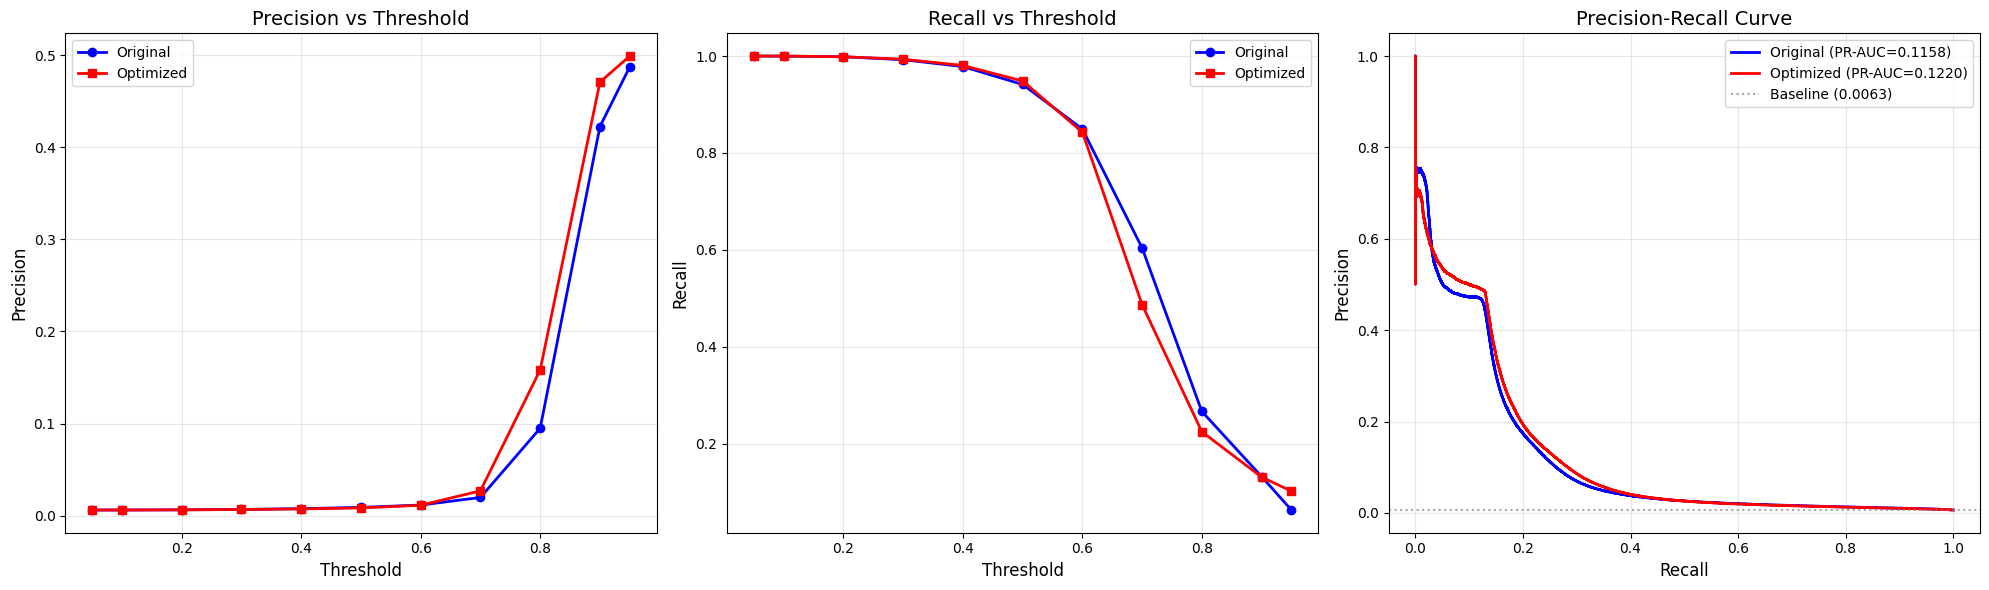


✅ Comparison plot saved to: D:\AI\dtsa_ml_ready\model_comparison.png


In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, average_precision_score, roc_auc_score
import matplotlib.pyplot as plt
import os

# --- 1. LOAD DATA & MODELS ---
DATA_DIR = r'D:\AI\dtsa_ml_ready'

print("Loading test data...")
df_test = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))
df_test = df_test[df_test['default_12m'].notna()].copy()

features = ['CLASSIC_FICO', 'PROXY_LTV', 'ORIGINAL LOAN TERM', 'LOAN AGE', 'GDP', 'UNEMPLOYMENT_RATE', 'HOME_PRICE_INDEX',
            'ORIGINAL_DTI', 'ORIGINAL_LTV', 'CHANNEL', 'ELTV', 'OCCUPANCY_STATUS', 'PAYMENT_SHOCK', 
            'BORROWER_ASSISTANCE_PLAN', 'PROPERTY_TYPE', 'LOAN_PURPOSE']

categorical_features = ['CHANNEL', 'OCCUPANCY_STATUS', 'BORROWER_ASSISTANCE_PLAN', 'PROPERTY_TYPE', 'LOAN_PURPOSE']

for col in categorical_features:
    if col in df_test.columns:
        df_test[col] = df_test[col].astype('category')

X_test = df_test[features]
y_test = df_test['default_12m'].astype(int)

print(f"Test set: {len(X_test):,} rows | Default rate: {y_test.mean():.4%}")

# Load both models
model_original = lgb.Booster(model_file=os.path.join(DATA_DIR, 'dtsa_default_12m_model.txt'))
model_optimized = lgb.Booster(model_file=os.path.join(DATA_DIR, 'dtsa_default_12m_model_OPTIMIZED.txt'))

# Get predictions
print("\nGenerating predictions from both models...")
y_pred_original = model_original.predict(X_test)
y_pred_optimized = model_optimized.predict(X_test)

# --- 2. THRESHOLD COMPARISON TABLE ---
thresholds = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

print("\n" + "="*120)
print("ORIGINAL MODEL vs OPTIMIZED MODEL: Precision & Recall Comparison")
print("="*120)
print(f"{'Threshold':<10} | {'Orig Prec':<10} {'Orig Rec':<10} {'Orig Flagged':<14} | {'Opt Prec':<10} {'Opt Rec':<10} {'Opt Flagged':<14} | {'PR Change':<10} {'Rec Change':<10}")
print("-"*120)

for t in thresholds:
    # Original model
    y_bin_orig = (y_pred_original >= t).astype(int)
    prec_orig = precision_score(y_test, y_bin_orig, zero_division=0)
    rec_orig = recall_score(y_test, y_bin_orig, zero_division=0)
    flagged_orig = y_bin_orig.sum()
    
    # Optimized model
    y_bin_opt = (y_pred_optimized >= t).astype(int)
    prec_opt = precision_score(y_test, y_bin_opt, zero_division=0)
    rec_opt = recall_score(y_test, y_bin_opt, zero_division=0)
    flagged_opt = y_bin_opt.sum()
    
    # Calculate changes
    prec_change = prec_opt - prec_orig
    rec_change = rec_opt - rec_orig
    
    print(f"{t:<10.2f} | {prec_orig:<10.4f} {rec_orig:<10.4f} {flagged_orig:<14,} | {prec_opt:<10.4f} {rec_opt:<10.4f} {flagged_opt:<14,} | {prec_change:<+10.4f} {rec_change:<+10.4f}")

# --- 3. OVERALL METRICS ---
print("\n" + "="*80)
print("OVERALL METRICS COMPARISON")
print("="*80)
print(f"{'Metric':<25} {'Original':<15} {'Optimized':<15} {'Change':<15}")
print("-"*80)

pr_orig = average_precision_score(y_test, y_pred_original)
pr_opt = average_precision_score(y_test, y_pred_optimized)
roc_orig = roc_auc_score(y_test, y_pred_original)
roc_opt = roc_auc_score(y_test, y_pred_optimized)

print(f"{'PR-AUC':<25} {pr_orig:<15.4f} {pr_opt:<15.4f} {pr_opt - pr_orig:<+15.4f}")
print(f"{'ROC-AUC':<25} {roc_orig:<15.4f} {roc_opt:<15.4f} {roc_opt - roc_orig:<+15.4f}")

# --- 4. PLOTS ---
print("\nGenerating comparison plots...")

# Plot 1: Precision vs Threshold
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].plot(thresholds, [precision_score(y_test, (y_pred_original >= t).astype(int), zero_division=0) for t in thresholds], 
             'b-o', label='Original', linewidth=2, markersize=6)
axes[0].plot(thresholds, [precision_score(y_test, (y_pred_optimized >= t).astype(int), zero_division=0) for t in thresholds], 
             'r-s', label='Optimized', linewidth=2, markersize=6)
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision vs Threshold', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Recall vs Threshold
axes[1].plot(thresholds, [recall_score(y_test, (y_pred_original >= t).astype(int), zero_division=0) for t in thresholds], 
             'b-o', label='Original', linewidth=2, markersize=6)
axes[1].plot(thresholds, [recall_score(y_test, (y_pred_optimized >= t).astype(int), zero_division=0) for t in thresholds], 
             'r-s', label='Optimized', linewidth=2, markersize=6)
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Recall', fontsize=12)
axes[1].set_title('Recall vs Threshold', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

prec_curve_orig, rec_curve_orig, _ = precision_recall_curve(y_test, y_pred_original)
prec_curve_opt, rec_curve_opt, _ = precision_recall_curve(y_test, y_pred_optimized)

axes[2].plot(rec_curve_orig, prec_curve_orig, 'b-', label=f'Original (PR-AUC={pr_orig:.4f})', linewidth=2)
axes[2].plot(rec_curve_opt, prec_curve_opt, 'r-', label=f'Optimized (PR-AUC={pr_opt:.4f})', linewidth=2)
axes[2].axhline(y=y_test.mean(), color='gray', linestyle=':', alpha=0.7, label=f'Baseline ({y_test.mean():.4f})')
axes[2].set_xlabel('Recall', fontsize=12)
axes[2].set_ylabel('Precision', fontsize=12)
axes[2].set_title('Precision-Recall Curve', fontsize=14)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'model_comparison.png'), dpi=150)
plt.show()

print(f"\n✅ Comparison plot saved to: {os.path.join(DATA_DIR, 'model_comparison.png')}")

In [3]:
# Series Delinquency Analysis(90+ Days DPD)
import os
NEW_TEMP_DIR = r"D:\AI\Temp"
os.makedirs(NEW_TEMP_DIR, exist_ok=True)
os.environ['TEMP'] = NEW_TEMP_DIR
os.environ['TMP'] = NEW_TEMP_DIR
print(f"✅ Temp directory forced to: {NEW_TEMP_DIR}")


import pandas as pd
import numpy as np
import time

# --- 1. SET PATHS ---
DATA_DIR = r'D:\AI\dtsa_ml_ready'


print("Loading datasets into memory...")
start_time = time.time()

# Load data
df_test = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))


def process_severe_delinquency_with_censoring(df, loan_id_col='LOAN IDENTIFIER', period_col='PERIOD', delinq_col='DELINQUENCY_STATUS'):
    """
    Processes loan performance data to identify true severe delinquency events (90+ DPD)
    while properly censoring suspicious jumps to XX/RA (likely payoffs/liquidations).
    """
    print("Processing delinquency censoring logic...")
    
    # 1. Sort chronologically to ensure correct period-to-period transitions
    df = df.sort_values([loan_id_col, period_col]).copy()
    
    # 2. Normalize the delinquency column (handle whitespace and ensure string)
    df['delinq_str'] = df[delinq_col].astype(str).str.strip()
    
    # 3. Define Severe Delinquency (90+ DPD, REO, or Liquidated)
    severe_codes = [str(i) for i in range(3, 100)] + ['RA', 'XX']
    df['is_severe'] = df['delinq_str'].isin(severe_codes).astype(int)
    
    # 4. Track historical severity per loan
    # Did this loan EVER hit severe delinquency in any PRIOR period?
    df['cum_severe'] = df.groupby(loan_id_col, observed=False)['is_severe'].cumsum()
    df['had_prior_severe'] = (df.groupby(loan_id_col, observed=False)['cum_severe'].shift(1).fillna(0) > 0).astype(int)
    
    # 5. Identify Scenario B: Suspicious Jumps
    # Condition: Current status is XX or RA, AND the loan never hit 3+ DPD in any prior period
    df['is_liquidation'] = df['delinq_str'].isin(['XX', 'RA']).astype(int)
    df['is_suspicious_jump'] = ((df['is_liquidation'] == 1) & (df['had_prior_severe'] == 0)).astype(int)
    
    # 6. Define the TRUE Hazard Target (Scenario A)
    # Target = 1 ONLY if it's the FIRST time hitting severe delinquency, AND it's not a suspicious jump
    df['is_true_default_event'] = (
        (df['is_severe'] == 1) & 
        (df['cum_severe'] == 1) &          # First time hitting severe
        (df['is_suspicious_jump'] == 0)    # Not a suspicious jump
    ).astype(int)
    
    # 7. Filter to "At-Risk" Dataset
    # We only keep:
    # - Rows where the loan is still performing (cum_severe == 0)
    # - The single row where the true default event occurs (is_true_default_event == 1)
    # - The single row where a suspicious jump occurs (to count it as a censored observation, target=0)
    df['keep_row'] = (df['cum_severe'] == 0) | (df['is_true_default_event'] == 1) | (df['is_suspicious_jump'] == 1)
    
    df_clean = df[df['keep_row']].copy()
    
    return df_clean

# Apply the function
df_test_clean = process_severe_delinquency_with_censoring(
    df_test, 
    loan_id_col='LOAN IDENTIFIER', 
    period_col='PERIOD', 
    delinq_col='CURRENT LOAN DELINQUENCY STATUS' # Adjust if your column name is slightly different
)

# --- DIAGNOSTIC SUMMARY ---
print("\n" + "="*60)
print("SEVERE DELINQUENCY CENSORING DIAGNOSTIC (TEST SET)")
print("="*60)

# 1. Overall Event Counts
total_loans = df_test_clean['LOAN IDENTIFIER'].nunique()
true_defaults = df_test_clean['is_true_default_event'].sum()
suspicious_jumps = df_test_clean['is_suspicious_jump'].sum()

print(f"Total Unique Loans Analyzed: {total_loans:,}")
print(f"True Severe Default Events (Scenario A): {true_defaults:,} ({true_defaults/total_loans:.4%})")
print(f"Suspicious Jumps to XX/RA (Scenario B, Censored): {suspicious_jumps:,} ({suspicious_jumps/total_loans:.4%})")

# 2. What do the suspicious jumps look like?
# Let's see the period number when these jumps happen
jump_analysis = df_test_clean[df_test_clean['is_suspicious_jump'] == 1].copy()
print("\n--- Timing of Suspicious Jumps (Period of XX/RA) ---")
print(jump_analysis['PERIOD'].describe())

# 3. What was the delinquency status RIGHT BEFORE the jump?
# (For loans with >1 period of history)
jump_with_history = jump_analysis[jump_analysis.groupby('LOAN IDENTIFIER')['PERIOD'].transform('count') > 1]
if len(jump_with_history) > 0:
    print("\n--- Status in Period Immediately Preceding Suspicious Jump ---")
    # Get the prior period's status for these specific loans
    # (We can infer this by looking at the max delinq_str for that loan where keep_row was true prior to the jump)
    # For simplicity, let's just show the distribution of the jump status itself
    print(jump_analysis['delinq_str'].value_counts())
else:
    print("\n(All suspicious jumps occurred in Period 1, indicating immediate payoff/liquidation)")

print("="*60)




✅ Temp directory forced to: D:\AI\Temp
Loading datasets into memory...
Processing delinquency censoring logic...

SEVERE DELINQUENCY CENSORING DIAGNOSTIC (TEST SET)
Total Unique Loans Analyzed: 764,958
True Severe Default Events (Scenario A): 46 (0.0060%)
Suspicious Jumps to XX/RA (Scenario B, Censored): 15,175 (1.9838%)

--- Timing of Suspicious Jumps (Period of XX/RA) ---
count     15175.000000
mean     202529.846919
std          47.708762
min      200004.000000
25%      202511.000000
50%      202511.000000
75%      202512.000000
max      202602.000000
Name: PERIOD, dtype: float64

(All suspicious jumps occurred in Period 1, indicating immediate payoff/liquidation)


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score
import time
import os

# --- 1. SET PATHS ---
DATA_DIR = r'D:\AI\dtsa_ml_ready'
MODEL_SAVE_PATH = os.path.join(DATA_DIR, 'dtsa_hazard_model_v4.txt')

print("Loading datasets into memory...")
start_time = time.time()

df_train = pd.read_parquet(os.path.join(DATA_DIR, 'train_balanced.parquet'))
df_val = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))
df_test = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))

print(f"✅ Loaded in {time.time() - start_time:.2f} seconds.")

# --- 2. FEATURE ENGINEERING ---
drop_cols = ['LOAN IDENTIFIER', 'PERIOD']
for df in [df_train, df_val, df_test]:
    df.drop(columns=drop_cols, inplace=True, errors='ignore')

target = 'default_event'
features = [col for col in df_train.columns if col != target]

categorical_features = [
    'OCCUPANCY STATUS', 
    'CHANNEL', 
    'AMORTIZATION TYPE', 
    'MODIFICATION FLAG',
    'NUMBER OF UNITS'
]

for df in [df_train, df_val, df_test]:
    for col in categorical_features:
        if col in df.columns:
            df[col] = df[col].astype('category')

X_train, y_train = df_train[features], df_train[target]
X_val, y_val = df_val[features], df_val[target]
X_test, y_test = df_test[features], df_test[target]

# --- 3. MODEL CONFIGURATION (STRONGER REGULARIZATION) ---
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.01,        # Slower learning to prevent memorization
    'num_leaves': 15,             # Much smaller trees (was 31)
    'max_depth': 5,               # Shallower splits (was 8)
    'min_child_samples': 1000,    # Require 1000+ loans per leaf to prevent overfitting to noisy DTI 999s
    'feature_fraction': 0.7,      # Randomly drop 30% of features per tree
    'bagging_fraction': 0.7,      # Randomly drop 30% of rows per tree
    'bagging_freq': 1,
    'verbose': -1,
    'n_jobs': -1
}

print("\nTraining LightGBM Discrete-Time Hazard Model (v4 - Regularized)...")
train_start = time.time()

lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
lgb_val = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_features, reference=lgb_train)

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    valid_names=['val'],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)] # Increased to 100 rounds
)

print(f"✅ Training completed in {time.time() - train_start:.2f} seconds.")
print(f"Best iteration: {model.best_iteration}")
model.save_model(MODEL_SAVE_PATH)

# --- 4. EVALUATION ---
print("\nEvaluating on Test Set...")
y_pred_prob = model.predict(X_test, num_iteration=model.best_iteration)

pr_auc = average_precision_score(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"🎯 Test PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"🎯 Test ROC-AUC: {roc_auc:.4f}")

# --- 5. SHAP INTERPRETABILITY (FIXED FOR NEWER SHAP VERSIONS) ---
print("\nCalculating SHAP values...")
shap_sample = X_test.sample(n=100000, random_state=42)

explainer = shap.TreeExplainer(model)
# LightGBM now returns a list: [class_0_shap, class_1_shap]
# We explicitly extract index [1] to get the impact on the DEFAULT event
shap_values_list = explainer.shap_values(shap_sample)
shap_values = shap_values_list[1] 

# Global Feature Importance
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP) - Impact on Default")
plt.tight_layout()
plt.show()

# SHAP Beeswarm (Directionality)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title("SHAP Feature Impact on Monthly Default Hazard")
plt.tight_layout()
plt.show()

print("\n🎉 PHASE 3 (V4) COMPLETE!")

Loading datasets into memory...
✅ Loaded in 11.35 seconds.

Default rate in training data: 0.0130

Training Isolation Forest Anomaly Detection Model...


[Parallel(n_jobs=28)]: Using backend ThreadingBackend with 28 concurrent workers.
[Parallel(n_jobs=28)]: Done   2 out of  28 | elapsed:    3.3s remaining:   44.0s
[Parallel(n_jobs=28)]: Done  28 out of  28 | elapsed:    3.9s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   18.8s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:  1.3min
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:  1.3min finished


✅ Training completed in 81.88 seconds.

Evaluating on Test Set...


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   11.5s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   50.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   50.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   11.4s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   43.6s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   43.8s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    9.5s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   38.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   38.2s finished


🎯 Test PR-AUC (Average Precision): 0.0008
🎯 Test ROC-AUC: 0.4961


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   10.6s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   47.2s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   47.5s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.1s finished


🎯 Val PR-AUC: 0.0011
🎯 Val ROC-AUC: 0.4368

Calculating SHAP values...


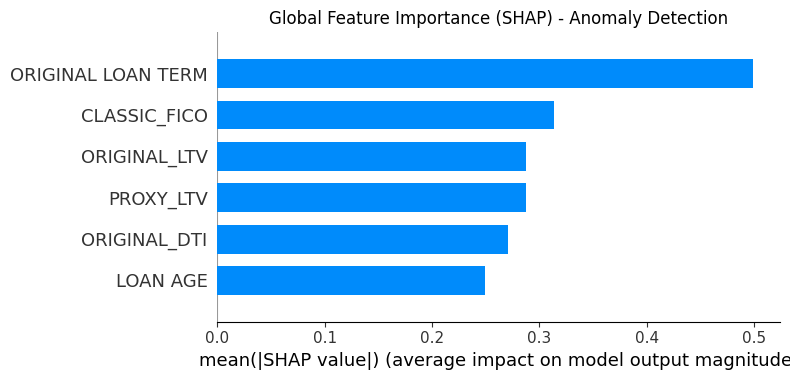

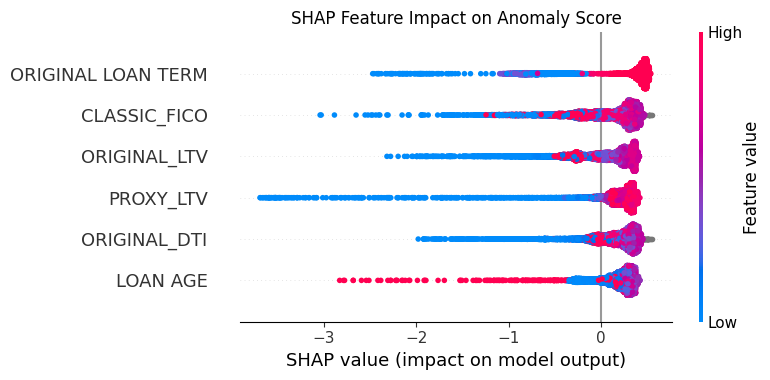


Analyzing predictions...


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   11.1s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   43.4s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   43.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   10.7s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   42.9s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   43.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    9.5s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   38.2s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   38.4s finished


Predicted anomalies: 87335 / 32303523 (0.27%)

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00  32277017
     Default       0.00      0.01      0.00     26506

    accuracy                           1.00  32303523
   macro avg       0.50      0.50      0.50  32303523
weighted avg       1.00      1.00      1.00  32303523


🎉 ISOLATION FOREST MODEL COMPLETE!


In [ ]:
# Isolation Forest Anomaly Detection Model for Default Prediction
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score
import time
import os

# --- 1. SET PATHS ---
DATA_DIR = r'D:\AI\dtsa_ml_ready'
MODEL_SAVE_PATH = os.path.join(DATA_DIR, 'dtsa_isolation_forest_v1.pkl')

print("Loading datasets into memory...")
start_time = time.time()

df_train = pd.read_parquet(os.path.join(DATA_DIR, 'train_balanced.parquet'))
df_val = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))
df_test = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))

print(f"✅ Loaded in {time.time() - start_time:.2f} seconds.")

# --- 2. FEATURE ENGINEERING ---
drop_cols = ['LOAN IDENTIFIER', 'PERIOD']
for df in [df_train, df_val, df_test]:
    df.drop(columns=drop_cols, inplace=True, errors='ignore')

target = 'default_event'
features = ['CLASSIC_FICO', 'PROXY_LTV', 'ORIGINAL LOAN TERM', 'LOAN AGE', 
             'ORIGINAL_DTI', 'ORIGINAL_LTV'
            ]



X_train, y_train = df_train[features], df_train[target]
X_val, y_val = df_val[features], df_val[target]
X_test, y_test = df_test[features], df_test[target]

# --- 3. MODEL CONFIGURATION ---
# Calculate contamination from training data (expected anomaly proportion)
contamination_rate = y_train.mean()
print(f"\nDefault rate in training data: {contamination_rate:.4f}")

params = {
    'n_estimators': 200,           # Number of trees (more = better, but slower)
    'max_samples': 'auto',         # Samples per tree (auto = min(256, n_samples))
    'contamination': contamination_rate,  # Expected proportion of outliers
    'max_features': 1.0,           # Features per tree (1.0 = all features)
    'bootstrap': False,            # Sample with replacement
    'n_jobs': -1,                  # Use all cores
    'random_state': 42,
    'verbose': 1
}

print("\nTraining Isolation Forest Anomaly Detection Model...")
train_start = time.time()

model = IsolationForest(**params)
model.fit(X_train)

print(f"✅ Training completed in {time.time() - train_start:.2f} seconds.")

# Save model
import joblib
joblib.dump(model, MODEL_SAVE_PATH)

# --- 4. EVALUATION ---
print("\nEvaluating on Test Set...")
# decision_function: negative = anomaly, positive = normal
# We negate it so higher scores = more likely to default (for AUC metrics)
y_pred_scores = -model.decision_function(X_test)

pr_auc = average_precision_score(y_test, y_pred_scores)
roc_auc = roc_auc_score(y_test, y_pred_scores)

print(f"🎯 Test PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"🎯 Test ROC-AUC: {roc_auc:.4f}")

# Also check predictions on validation set
y_val_scores = -model.decision_function(X_val)
val_pr_auc = average_precision_score(y_val, y_val_scores)
val_roc_auc = roc_auc_score(y_val, y_val_scores)
print(f"🎯 Val PR-AUC: {val_pr_auc:.4f}")
print(f"🎯 Val ROC-AUC: {val_roc_auc:.4f}")

# --- 5. SHAP INTERPRETABILITY ---
print("\nCalculating SHAP values...")
shap_sample = X_test.sample(n=10000, random_state=42)  # Smaller sample for speed

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(shap_sample)

# For Isolation Forest, SHAP shows what makes samples anomalous
# Global Feature Importance
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP) - Anomaly Detection")
plt.tight_layout()
plt.show()

# SHAP Beeswarm (Directionality)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title("SHAP Feature Impact on Anomaly Score")
plt.tight_layout()
plt.show()

# --- 6. ADDITIONAL ANALYSIS ---
print("\nAnalyzing predictions...")
y_pred_labels = model.predict(X_test)  # 1 = normal, -1 = anomaly
anomaly_count = (y_pred_labels == -1).sum()
print(f"Predicted anomalies: {anomaly_count} / {len(X_test)} ({anomaly_count/len(X_test)*100:.2f}%)")

# Confusion matrix style analysis
from sklearn.metrics import confusion_matrix, classification_report
y_true_binary = y_test.values
y_pred_binary = (y_pred_labels == -1).astype(int)

print("\nClassification Report:")
print(classification_report(y_true_binary, y_pred_binary, target_names=['Normal', 'Default']))

print("\n🎉 ISOLATION FOREST MODEL COMPLETE!")

In [12]:
import duckdb
import pandas as pd
import os
import time

ORIG_PARQUET_PATH = r"D:\AI\master_orig_dataset\*.parquet"  # adjust as needed
ORIG_SAMPLE_PATH = r"D:\AI\orig_sample.parquet"


# --- CONFIGURE DUCKDB ---
con = duckdb.connect()
con.execute("SET memory_limit='75GB';")
con.execute("SET threads=28;")


orig_query = f"""
    COPY (
        SELECT 
            "LOAN IDENTIFIER",
            
            -- CONTINUOUS VARIABLES (clean sentinel values)
            CASE WHEN CAST("CLASSIC FICO" AS VARCHAR) IN ('9999') 
                 THEN NULL 
                 ELSE TRY_CAST("CLASSIC FICO" AS INTEGER) 
            END AS CLASSIC_FICO,
            
            CASE WHEN CAST("ORIGINAL LOAN-TO-VALUE (LTV)" AS VARCHAR) IN ('999') 
                 THEN NULL 
                 ELSE TRY_CAST("ORIGINAL LOAN-TO-VALUE (LTV)" AS INTEGER) 
            END AS ORIGINAL_LTV,
            
            CASE WHEN CAST("ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)" AS VARCHAR) IN ('999') 
                 THEN NULL 
                 ELSE TRY_CAST("ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)" AS INTEGER) 
            END AS ORIGINAL_CLTV,
            
            CASE WHEN CAST("ORIGINAL DEBT-TO-INCOME (DTI) RATIO" AS VARCHAR) IN ('999') 
                 THEN NULL 
                 ELSE TRY_CAST("ORIGINAL DEBT-TO-INCOME (DTI) RATIO" AS INTEGER) 
            END AS ORIGINAL_DTI,
            
            TRY_CAST("ORIGINAL INTEREST RATE" AS DOUBLE) AS ORIGINAL_INTEREST_RATE,
            TRY_CAST("ORIGINAL UPB" AS DOUBLE) AS ORIGINAL_UPB,
            TRY_CAST("ORIGINAL LOAN TERM" AS INTEGER) AS ORIGINAL_LOAN_TERM,
            TRY_CAST("MORTGAGE INSURANCE PERCENTAGE (MI %)" AS DOUBLE) AS MI_PERCENTAGE,
            
            -- CATEGORICAL VARIABLES
            CASE WHEN CAST("CHANNEL" AS VARCHAR) IN ('9') THEN 'Missing' 
                 ELSE CAST("CHANNEL" AS VARCHAR) END AS CHANNEL,
            CASE WHEN CAST("OCCUPANCY STATUS" AS VARCHAR) IN ('9') THEN 'Missing' 
                 ELSE CAST("OCCUPANCY STATUS" AS VARCHAR) END AS OCCUPANCY_STATUS,
            CASE WHEN CAST("LOAN PURPOSE" AS VARCHAR) IN ('9') THEN 'Missing' 
                 ELSE CAST("LOAN PURPOSE" AS VARCHAR) END AS LOAN_PURPOSE,
            CASE WHEN CAST("PROPERTY TYPE" AS VARCHAR) IN ('99') THEN 'Missing' 
                 ELSE CAST("PROPERTY TYPE" AS VARCHAR) END AS PROPERTY_TYPE,
            CASE WHEN CAST("FIRST TIME HOMEBUYER INDICATOR" AS VARCHAR) IN ('9') THEN 'Missing' 
                 ELSE CAST("FIRST TIME HOMEBUYER INDICATOR" AS VARCHAR) END AS FIRST_TIME_HOMEBUYER,


     
            "AMORTIZATION TYPE",
            "METROPOLITAN STATISTICAL AREA (MSA) OR METROPOLITAN DIVISION" AS "METRO", 
            "SELLER NAME",
            "NUMBER OF UNITS" AS "NUMBER_OF_UNITS",
            "FIRST PAYMENT DATE" AS "FIRST_PAYMENT_DATE"

            
        FROM read_parquet('{ORIG_PARQUET_PATH}', union_by_name=true)
        USING SAMPLE 5 PERCENT
    ) TO '{ORIG_SAMPLE_PATH}' (FORMAT PARQUET, COMPRESSION ZSTD);
"""

con.execute(orig_query)
print("✅ Origination sample saved.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Origination sample saved.
